# HMM-mixed MVO (EW)

Supervised HMM on the equal-weight train slice (2001-01-01 through 2014-01-03). Test (2014-01-06 to 2022-08-31) is used for a four-line regime plot and a non-overlapping mean-variance backtest.

This notebook is the EW counterpart of `hmm-mixed-mvo.ipynb`, except mixing is **row-append** rather than column-stack. Regime labels, HMM emissions, and specialist pools come from `HMM-Diffusion-EW.ipynb` (`configs/ew.yaml`). There is no validation slice.

Both methods keep the same real lookback of 252 days × 10 assets and **row-append** synthetic days so that the **overall synth share** of the training matrix is 0%, 10%, …, 90%: `synth_rows / (real_rows + synth_rows)`. Markowitz stays on the original 10 assets.

- `0%`: `252 × 10` (real lookback only).
- `10%`: `280 × 10` (28 synth days).
- `20%`: `315 × 10` (63 synth days).
- `90%`: `2520 × 10` (2268 synth days).

- **hmm-diffusion**: synth days from the EW specialist pool for predicted regime `k*`. `k*` is the **window average argmax** of the open-loop daily labels on that hold.
- **uncondi-diffusion**: synth days from `trained_diffusion_withoutregime/generated_data.csv`.

On each hold the regime forecast uses the transition matrix only. Emissions on that hold are applied after scoring, and only on those 63 days.

Run the EW scripts first so labels and specialist pools exist:

```
python scripts/01_label_regimes_ew.py
python scripts/02_build_diffusion_dataset_ew.py
python scripts/03_train_specialists_ew.py
python scripts/04_generate_pools_ew.py
```

Markowitz is sum-to-1 with shorts allowed; no max-weight cap in the default sweep.


In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

from hmmdiff.config import bootstrap_imports, config_path, load_config

cfg = load_config("configs/ew.yaml")
bootstrap_imports()

from hmmdiff import data, ew, models, plots, pools, regimes
from hmmdiff.mvo import (
    load_specialist_pools,
    load_uncond_windows,
    run_mvo_backtest,
    run_scale_check,
    synth_rows_for_share,
    walk_open_loop,
)

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

HORIZON = 63
STEP = 63
LOOKBACK = 252
MIX_MODE = "row"
MIX_GRID = list(range(0, 91, 10))
RANDOM_STATE = 42
N_REGIMES = int(cfg["regimes"]["n_regimes"])
TOP_K = int(cfg["hmm"]["top_k"])
ASSET_COLS = list(cfg["data"]["asset_columns"])
UNCOND_CSV = REPO_ROOT / "trained_diffusion_withoutregime" / "generated_data.csv"
PLOT_ROOT = REPO_ROOT / "plots" / "ew"

print(
    f"{N_REGIMES} regimes, lookback {LOOKBACK}, hold {HORIZON}, step {STEP}, "
    f"mix {MIX_MODE}, synth share {MIX_GRID[0]}..{MIX_GRID[-1]}%"
)
print("config configs/ew.yaml")


5 regimes, lookback 252, hold 63, step 63, mix row, synth share 0..90%
config configs/ew.yaml


## Setup


In [2]:
returns = ew.load_ew_returns(cfg)
counts = ew.split_counts(returns)
labels = regimes.load_labels(config_path(cfg, "regime_labels"))
regime_labels = labels.labels.astype(int)

train_data, test_data = ew.build_train_test_frames(returns, regime_labels)
_, test_regimes = ew.split_labels(returns, regime_labels)

test_dates = pd.to_datetime(returns.loc[ew.test_mask(returns), "date"])
train_dates = pd.to_datetime(returns.loc[ew.train_mask(returns), "date"])

log_panel = data.build_multivariate_log_returns(cfg)[ASSET_COLS]
simple_panel = np.expm1(log_panel)
simple_panel.index = pd.to_datetime(simple_panel.index)

pools_root = config_path(cfg, "pools")
if not pools.pools_available(pools_root, N_REGIMES):
    raise FileNotFoundError(
        f"EW specialist pools not found under {pools_root}. "
        "Run scripts/03_train_specialists_ew.py and scripts/04_generate_pools_ew.py."
    )
specialist_pools = load_specialist_pools(pools_root, N_REGIMES)
uncond_windows = load_uncond_windows(UNCOND_CSV)

print(f"returns      {counts['n_returns']:>6}  {counts['start_date']} to {counts['end_date']}")
print(f"train        {counts['n_train']:>6}  {train_dates.iloc[0].date()} to {train_dates.iloc[-1].date()}")
print(f"test         {counts['n_test']:>6}  {test_dates.iloc[0].date()} to {test_dates.iloc[-1].date()}")
print(f"10-asset panel {len(simple_panel):>5}  {simple_panel.index[0].date()} to {simple_panel.index[-1].date()}")
print(f"uncond windows {uncond_windows.shape}")
print(f"specialist pools {[specialist_pools[k].shape for k in range(N_REGIMES)]}")

assert str(test_dates.iloc[0].date()) == "2014-01-06"
assert str(test_dates.iloc[-1].date()) == "2022-08-31"
assert counts["n_train"] == cfg["reference"]["n_train"]
assert counts["n_test"] == cfg["reference"]["n_test"]
assert len(test_regimes) == len(test_dates)


returns        5653  2001-01-01 to 2022-08-31
train          3395  2001-01-01 to 2014-01-03
test           2258  2014-01-06 to 2022-08-31
10-asset panel  5653  2001-01-01 to 2022-08-31
uncond windows (1024, 128, 10)
specialist pools [(128, 128, 10), (128, 128, 10), (128, 128, 10), (128, 128, 10), (128, 128, 10)]


## Fit supervised HMM


In [3]:
coverage = pd.DataFrame(
    {
        "train": np.bincount(train_data.regime.values, minlength=N_REGIMES),
        "test": np.bincount(test_data.regime.values, minlength=N_REGIMES),
    },
    index=pd.Index(range(N_REGIMES), name="regime"),
)
display(coverage)

missing_train = coverage.index[coverage["train"] == 0].tolist()
assert not missing_train, (
    f"Regimes {missing_train} are absent from the training slice. "
    "Re-run scripts/01_label_regimes_ew.py."
)
missing_test = coverage.index[coverage["test"] == 0].tolist()
if missing_test:
    print(f"Test does not contain regimes {missing_test}; accuracy uses observed labels.")

init_dist = models.initial_distribution(train_data, N_REGIMES)
supervised = models.fit_supervised_hmm(train_data, N_REGIMES, cfg)

index = pd.Index(range(N_REGIMES), name="from")
columns = pd.Index(range(N_REGIMES), name="to")
print("Posterior transition matrix")
display(pd.DataFrame(supervised.transmat.round(3), index=index, columns=columns))
print("Emission parameters")
display(supervised.summary())
print("Initial distribution (train frequencies)")
display(pd.Series(init_dist, index=range(N_REGIMES), name="pi0"))


,train,test
regime,,
0,255,905
1,1785,815
2,875,275
3,280,163
4,200,100


sample: 100%|██████████| 300/300 [00:06<00:00, 49.96it/s, 31 steps of size 1.83e-01. acc. prob=0.91] 

Posterior transition matrix


to,0,1,2,3,4
from,,,,,
0,0.9900,0.0010,0.0080,0.0010,0.0010
1,0.0010,0.9960,0.0020,0.0020,0.0000
2,0.0010,0.0040,0.9930,0.0000,0.0010
3,0.0010,0.0110,0.0010,0.9870,0.0010
4,0.0010,0.0060,0.0010,0.0010,0.9910


Emission parameters


,mean,sigma
regime,,
0,0.0143,0.4800
1,0.0747,0.6868
2,-0.0300,0.9242
3,-0.0752,1.3825
4,-0.1354,2.7122


Initial distribution (train frequencies)


0   0.0751
1   0.5258
2   0.2577
3   0.0825
4   0.0589
Name: pi0, dtype: float64

## Rolling open-loop forecast


In [4]:
walk = walk_open_loop(
    train_data.emission.values,
    test_data.emission.values,
    supervised.transmat,
    supervised.mu,
    supervised.sigma,
    init_dist,
    horizon=HORIZON,
    step=STEP,
)

print(f"holds {len(walk.hold_starts)}  first test day {test_dates.iloc[0].date()}")
print(
    "hmm-diffusion k* = window average argmax; "
    f"first hold k* {int(walk.hold_k_star[0])}  last hold k* {int(walk.hold_k_star[-1])}"
)
print(
    "open-loop days filled",
    int(np.isfinite(walk.daily_argmax).sum()),
    "of",
    len(test_regimes),
)
print(
    f"first hold start {test_dates.iloc[int(walk.hold_starts[0])].date()}  "
    f"last hold start {test_dates.iloc[int(walk.hold_starts[-1])].date()}"
)


holds 35  first test day 2014-01-06
hmm-diffusion k* = window average argmax; first hold k* 0  last hold k* 3
open-loop days filled 2205 of 2258
first hold start 2014-01-06  last hold start 2022-03-23


## Regime plot and accuracy

Three comparisons versus clustering truth on the **test** slice:

1. **Forward-backward** — daily argmax of smoothed regime probabilities (uses emissions). Compared with daily clustering labels.
2. **Daily argmax** — each day's argmax of the open-loop regime probability (transition matrix only). Compared with daily clustering labels.
3. **Window average argmax** — one occupancy label per 63-day hold, copied to every day in that hold. Compared with daily clustering labels. **hmm-diffusion MVO samples all `n` synth windows from this regime's pool.**


100%|██████████| 2258/2258 [00:00<00:00, 96459.08it/s]
2258it [00:00, 94857.26it/s]


,truth,accuracy
estimate,,
Forward-backward,daily clustering labels,0.7511
Daily argmax,daily clustering labels,0.5211
Window average argmax,daily clustering labels,0.5351


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


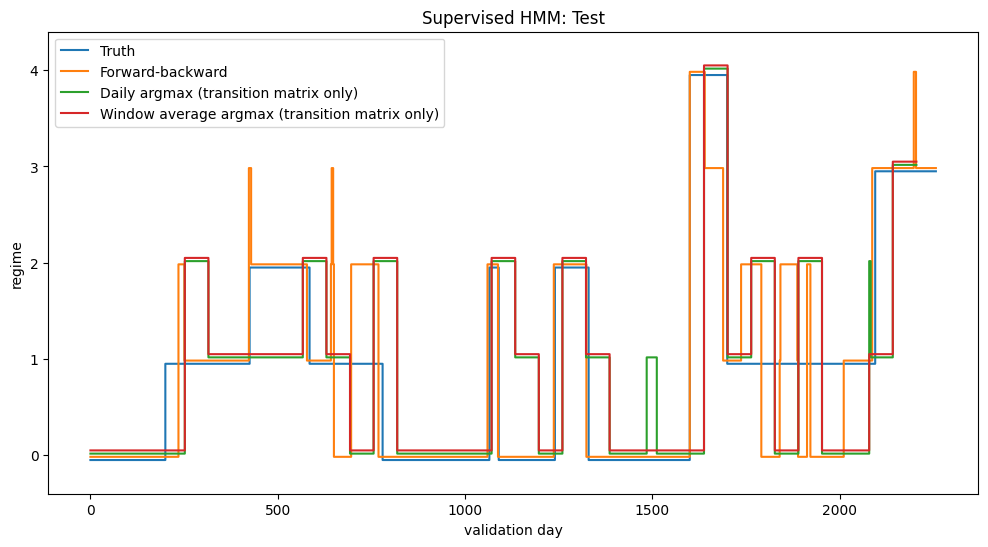

In [5]:
fb_probs, fb_est = models.estimate_states(
    supervised, test_data.emission.values, init_dist, N_REGIMES
)

present = sorted(set(test_regimes.tolist()))
missing = [k for k in range(N_REGIMES) if k not in present]
if missing:
    print(f"Test does not contain regimes {missing}; accuracy uses observed labels.")

fb_acc = models.accuracy_report(test_regimes, fb_est, fb_probs, N_REGIMES, TOP_K)

daily_mask = np.isfinite(walk.daily_argmax)
daily_est = walk.daily_argmax[daily_mask].astype(int)
daily_truth = test_regimes[daily_mask]
daily_score = walk.open_loop_pi[daily_mask]
daily_acc = models.accuracy_report(daily_truth, daily_est, daily_score, N_REGIMES, TOP_K)

window_daily_score = np.full((len(test_regimes), N_REGIMES), np.nan)
for start in walk.hold_starts:
    sl = slice(int(start), int(start) + HORIZON)
    est_states = walk.daily_argmax[sl].astype(int)
    est_avg = np.eye(N_REGIMES)[est_states].mean(axis=0)
    window_daily_score[sl] = est_avg
window_daily_est = walk.window_argmax[daily_mask].astype(int)
window_daily_acc = models.accuracy_report(
    daily_truth, window_daily_est, window_daily_score[daily_mask], N_REGIMES, TOP_K
)

acc_table = pd.DataFrame(
    [
        {
            "estimate": "Forward-backward",
            "truth": "daily clustering labels",
            **fb_acc,
        },
        {
            "estimate": "Daily argmax",
            "truth": "daily clustering labels",
            **daily_acc,
        },
        {
            "estimate": "Window average argmax",
            "truth": "daily clustering labels",
            **window_daily_acc,
        },
    ]
).set_index("estimate")
display(acc_table[["truth", "accuracy"]])

plots.plot_regime_paths(
    {
        "Truth": test_regimes,
        "Forward-backward": fb_est,
        "Daily argmax (transition matrix only)": walk.daily_argmax,
        "Window average argmax (transition matrix only)": walk.window_argmax,
    },
    "Supervised HMM: Test",
    jiggle=0.05,
    save_path=PLOT_ROOT / "regime" / "supervised_hmm_test.eps",
)


## Scale check


In [6]:
first_hold_date = test_dates.iloc[int(walk.hold_starts[0])]
prior = simple_panel.loc[simple_panel.index < first_hold_date]
lookback_start = prior.index[-LOOKBACK]
real_ref = np.log1p(simple_panel.loc[lookback_start:test_dates.iloc[-1], ASSET_COLS].to_numpy())

scale = run_scale_check(real_ref, specialist_pools, uncond_windows, ASSET_COLS)
display(scale.table)
if not scale.ok:
    for line in scale.messages:
        print(f"[FAIL] {line}")
    raise SystemExit("Scale check failed; synth units do not match real MVO inputs.")
print("[OK] native log-return scale; simple-return std within 0.1×–10× of real")


,source,asset,native_std,simple_mean,simple_std,simple_min,simple_max,simple_p01,simple_p99
0,real,A001,0.0108,0.0005,0.0107,-0.1198,0.0939,-0.0323,0.0249
1,real,A004,0.0024,0.0001,0.0024,-0.0207,0.0108,-0.0062,0.0056
2,real,A006,0.0006,0.0000,0.0006,-0.0053,0.0039,-0.0018,0.0020
3,real,A008,0.0031,0.0002,0.0030,-0.0312,0.0308,-0.0092,0.0078
4,real,A009,0.0039,0.0001,0.0038,-0.0504,0.0357,-0.0096,0.0093
5,real,A011,0.0114,0.0005,0.0114,-0.1321,0.1082,-0.0306,0.0265
6,real,A012,0.0137,0.0004,0.0136,-0.1421,0.0940,-0.0358,0.0312
7,real,A013,0.0090,0.0002,0.0089,-0.1036,0.0716,-0.0252,0.0217
8,real,A014,0.0098,0.0001,0.0098,-0.0670,0.0574,-0.0266,0.0236
9,real,A015,0.0128,0.0003,0.0127,-0.1885,0.0905,-0.0329,0.0285


[OK] native log-return scale; simple-return std within 0.1×–10× of real


## MVO config

Lookback, hold, and step are trading-day counts. Later cells keep these windows and only change objective or constraints. Holds start on 2014-01-06 and stay inside the test slice through 2022-08-31. Mixing is row-append: the training matrix stays 10 columns and grows in rows.


In [7]:
from hmmdiff.mvo.backtest import lookback_and_hold, window_vol_bucket
from hmmdiff.mvo.portfolio_core import TRADING_DAYS, sharpe_ratio

n_assets = len(ASSET_COLS)
mvo_config = pd.DataFrame(
    [
        ("lookback", LOOKBACK, "trading days for μ and Σ"),
        ("hold / horizon", HORIZON, "days the weights are held"),
        ("step", STEP, "days between consecutive hold starts"),
        ("non-overlapping", STEP == HORIZON, "step equals hold"),
        ("mix grid", f"{MIX_GRID[0]}–{MIX_GRID[-1]}%", "synth share of the training matrix"),
        ("n assets", n_assets, ", ".join(ASSET_COLS)),
        ("random state", RANDOM_STATE, "seed + hold_start + n_synth"),
        ("ridge", 1e-6, "covariance diagonal; raised if T ≤ n_feat"),
        ("k*", "window average argmax", "hmm-diffusion specialist pool"),
        ("mix mode", MIX_MODE, "row-append synth under the real lookback"),
        ("default objective", "mean-variance", "later cells override"),
        ("default constraints", "unconstrained", "shorts allowed, no name cap"),
        ("synth window length", int(uncond_windows.shape[1]), "must be ≥ hold"),
        ("uncond pool size", int(uncond_windows.shape[0]), "regime-free CSV"),
        (
            "specialist pool size",
            int(next(iter(specialist_pools.values())).shape[0]),
            "windows per EW regime",
        ),
        ("train matrix 0%", f"{LOOKBACK} × {n_assets}", "real lookback only"),
        (
            f"train matrix {MIX_GRID[-1]}%",
            f"{LOOKBACK + synth_rows_for_share(LOOKBACK, MIX_GRID[-1] / 100.0)} × {n_assets}",
            "real plus row-appended synth",
        ),
    ],
    columns=["parameter", "value", "note"],
)
display(mvo_config)

hold_rows = []
for i, start in enumerate(walk.hold_starts.tolist()):
    start = int(start)
    sliced = lookback_and_hold(
        simple_panel[ASSET_COLS], test_dates.to_numpy(), start, LOOKBACK, HORIZON
    )
    hold_labels = test_regimes[start : start + HORIZON]
    hold_rows.append(
        {
            "hold": i,
            "start": test_dates.iloc[start].date(),
            "end": test_dates.iloc[start + HORIZON - 1].date(),
            "complete": sliced is not None,
            "bucket": window_vol_bucket(hold_labels),
            "k_star": int(walk.hold_k_star[i]),
        }
    )
holds = pd.DataFrame(hold_rows)
print(
    f"holds scheduled {len(holds)}  complete {int(holds['complete'].sum())}  "
    f"skipped {int((~holds['complete']).sum())}  "
    f"first {holds['start'].iloc[0]}  last start {holds['start'].iloc[-1]}"
)
display(holds["bucket"].value_counts().rename_axis("bucket").to_frame("n_holds"))
display(holds["k_star"].value_counts().sort_index().rename_axis("k*").to_frame("n_holds"))

test_simple = simple_panel.reindex(pd.DatetimeIndex(test_dates))[ASSET_COLS]
ann_mu = test_simple.mean() * TRADING_DAYS
ann_sd = test_simple.std(ddof=0) * np.sqrt(TRADING_DAYS)
asset_stats = pd.DataFrame({"ann_mu": ann_mu, "ann_sd": ann_sd, "sharpe": ann_mu / ann_sd})
pair_corr = test_simple.corr().to_numpy()
mean_pair_corr = float(pair_corr[np.triu_indices_from(pair_corr, k=1)].mean())
ew_port = test_simple.mean(axis=1).to_numpy()
print(
    f"test panel {test_simple.dropna(how='any').shape[0]} days  "
    f"mean pairwise corr {mean_pair_corr:.3f}  "
    f"equal-weight Sharpe {sharpe_ratio(ew_port):.3f}"
)
display(asset_stats.T)


,parameter,value,note
0,lookback,252,trading days for μ and Σ
1,hold / horizon,63,days the weights are held
2,step,63,days between consecutive hold starts
3,non-overlapping,True,step equals hold
4,mix grid,0–90%,synth share of the training matrix
5,n assets,10,"A001, A004, A006, A008, A009, A011, A012, A013..."
6,random state,42,seed + hold_start + n_synth
7,ridge,0.0000,covariance diagonal; raised if T ≤ n_feat
8,k*,window average argmax,hmm-diffusion specialist pool
9,mix mode,row,row-append synth under the real lookback


holds scheduled 35  complete 35  skipped 0  first 2014-01-06  last start 2022-03-23


,n_holds
bucket,
low vol,28
high vol,7


,n_holds
k*,
0,17
1,9
2,7
3,1
4,1


test panel 2258 days  mean pairwise corr 0.373  equal-weight Sharpe 0.576


,A001,A004,A006,A008,A009,A011,A012,A013,A014,A015
ann_mu,0.1199,0.0175,0.0093,0.0371,0.0233,0.1022,0.0898,0.0325,0.0375,0.0958
ann_sd,0.1756,0.0378,0.0103,0.0500,0.0604,0.1858,0.2220,0.1435,0.1575,0.2053
sharpe,0.6829,0.4636,0.9030,0.7421,0.3858,0.5498,0.4044,0.2267,0.2380,0.4668


## MVO backtest

`MIX_GRID` is the synth **share of the whole training matrix**: `synth_rows / (252 + synth_rows)`. 0% is real lookback only. Plots show 0% through 90%.


In [8]:
result = run_mvo_backtest(
    simple_panel[ASSET_COLS],
    test_dates.to_numpy(),
    test_regimes,
    walk,
    specialist_pools,
    uncond_windows,
    MIX_GRID,
    lookback=LOOKBACK,
    horizon=HORIZON,
    random_state=RANDOM_STATE,
    allow_short=True,
    mix_mode=MIX_MODE,
)

n0 = result.windows.loc[result.windows["n_synth"] == 0]
if n0.empty:
    raise SystemExit("No completed MVO holds.")
hmm_n0 = n0.loc[n0["method"] == "hmm-diffusion", ["hold_start", "sharpe", "calmar"]]
uncond_n0 = n0.loc[n0["method"] == "uncondi-diffusion", ["hold_start", "sharpe", "calmar"]]
merged = hmm_n0.merge(uncond_n0, on="hold_start", suffixes=("_hmm", "_uncond"))
sharpe_gap = float(np.nanmax(np.abs(merged["sharpe_hmm"] - merged["sharpe_uncond"])))
calmar_gap = float(np.nanmax(np.abs(merged["calmar_hmm"] - merged["calmar_uncond"])))
print(f"holds scored {merged.shape[0]}  n=0 max |Δ Sharpe| {sharpe_gap:.6g}  |Δ Calmar| {calmar_gap:.6g}")
if sharpe_gap > 1e-10 or calmar_gap > 1e-10:
    raise SystemExit("n=0 hmm-diffusion and uncondi-diffusion should match.")

print("bucket counts at n=0")
display(n0.loc[n0["method"] == "hmm-diffusion", "bucket"].value_counts())
print(
    f"first hold {result.windows['start_date'].min().date()}  "
    f"last hold start {result.windows['start_date'].max().date()}"
)
assert str(result.windows["start_date"].min().date()) == "2014-01-06"


holds scored 35  n=0 max |Δ Sharpe| 0  |Δ Calmar| 0
bucket counts at n=0


bucket
low vol     28
high vol     7
Name: count, dtype: int64

first hold 2014-01-06  last hold start 2022-03-23


## Sharpe and Calmar

The x-axis is **% of synth in the training matrix**: `synth_rows / (real_rows + synth_rows)`. Ticks are 0, 10, 20, …, 90. 0% is all real lookback.


Row-append mix: % of synth is synth_rows / (real_rows + synth_rows). Real lookback stays 252 × 10. 10% adds 28 days; 20% adds 63 days; 90% adds 2268 days.


,synth_pct,real_rows,real_cols,synth_rows,train_rows,train_matrix,synth_row_share
0,0,252,10,0,252,252 × 10,0.0000
1,10,252,10,28,280,280 × 10,0.1000
2,20,252,10,63,315,315 × 10,0.2000
3,30,252,10,108,360,360 × 10,0.3000
4,40,252,10,168,420,420 × 10,0.4000
5,50,252,10,252,504,504 × 10,0.5000
6,60,252,10,378,630,630 × 10,0.6000
7,70,252,10,588,840,840 × 10,0.7000
8,80,252,10,1008,1260,1260 × 10,0.8000
9,90,252,10,2268,2520,2520 × 10,0.9000


,method,n_synth,synth_pct,bucket,n_windows,sharpe_mean,sharpe_median,calmar_mean,calmar_median,return_mean,return_median,variance_mean,variance_median
0,hmm-diffusion,0,0.0000,high vol,7,-0.7417,-0.5453,-2.6884,-3.4219,-2.6084,-3.3861,27.4461,10.5495
20,uncondi-diffusion,0,0.0000,high vol,7,-0.7417,-0.5453,-2.6884,-3.4219,-2.6084,-3.3861,27.4461,10.5495
2,hmm-diffusion,10,10.0000,high vol,7,-1.1740,-1.1350,-5.4369,-3.9208,-5.2292,-3.8916,38.6680,15.4625
22,uncondi-diffusion,10,10.0000,high vol,7,-1.1325,-1.6979,-6.0134,-5.4446,-6.9235,-5.2899,52.6468,9.9937
4,hmm-diffusion,20,20.0000,high vol,7,-1.2190,-1.2193,-6.1605,-3.0498,-6.3652,-2.8958,46.9245,7.6204
24,uncondi-diffusion,20,20.0000,high vol,7,-1.1093,-1.3550,-8.2992,-7.5854,-8.3450,-7.0559,56.0322,11.5490
6,hmm-diffusion,30,30.0000,high vol,7,-1.3722,-1.1697,-9.7379,-5.0407,-9.8949,-5.0391,62.9094,11.9419
26,uncondi-diffusion,30,30.0000,high vol,7,-1.5241,-1.7587,-6.1955,-8.5203,-10.5222,-9.9273,76.3459,13.1635
8,hmm-diffusion,40,40.0000,high vol,7,-1.7470,-1.3406,-6.9941,-5.0791,-11.6568,-8.3181,86.3736,17.7430
28,uncondi-diffusion,40,40.0000,high vol,7,-1.1549,-2.3452,-5.1348,-1.8646,-15.4678,-13.2629,139.4651,27.3723


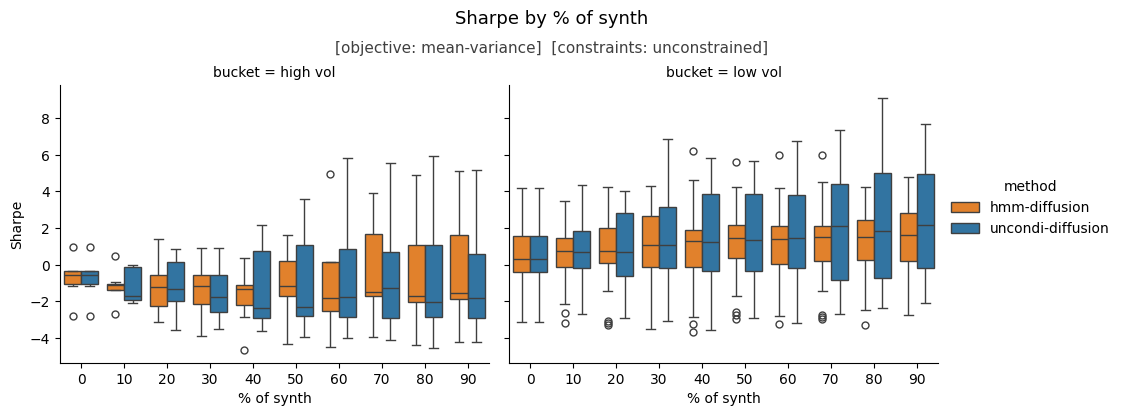

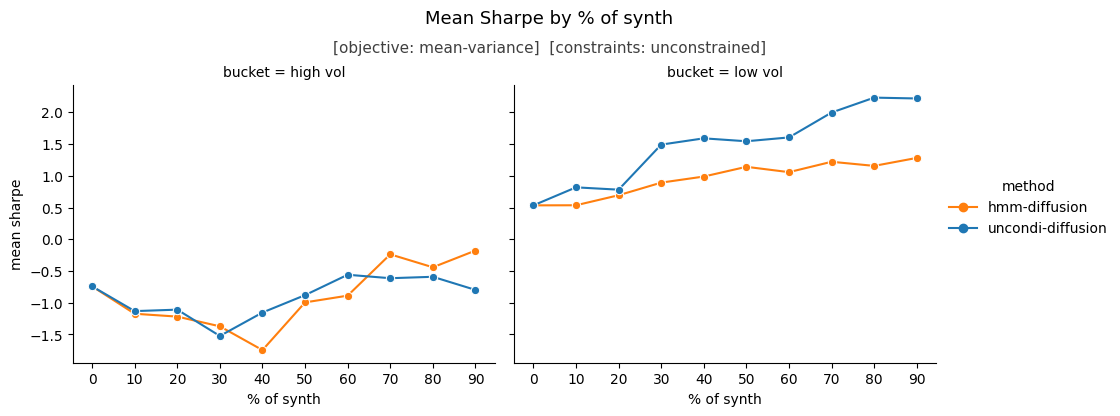

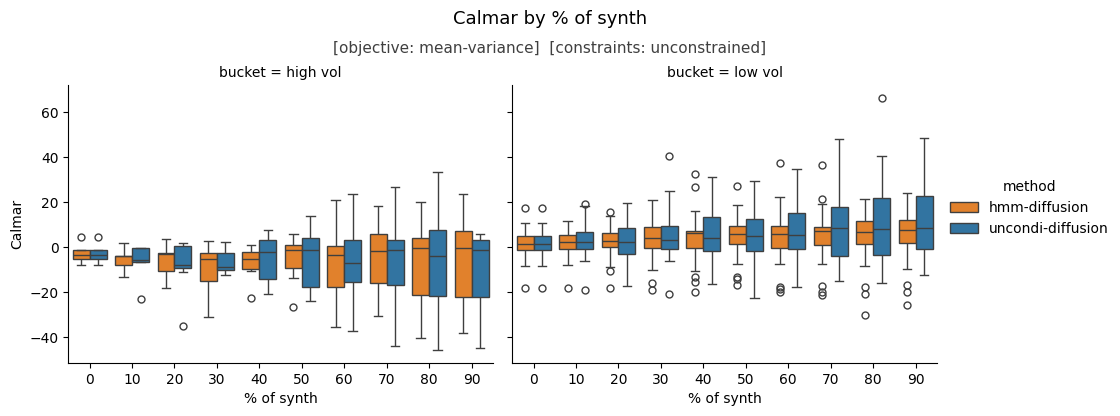

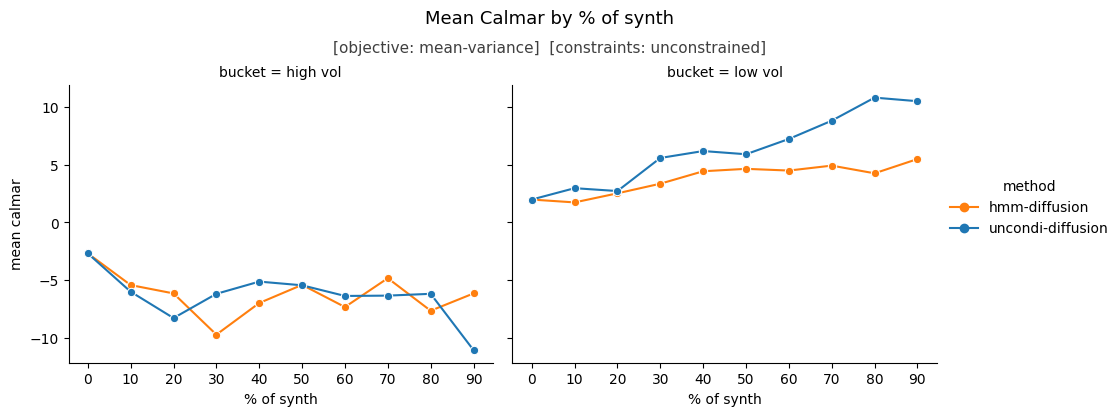

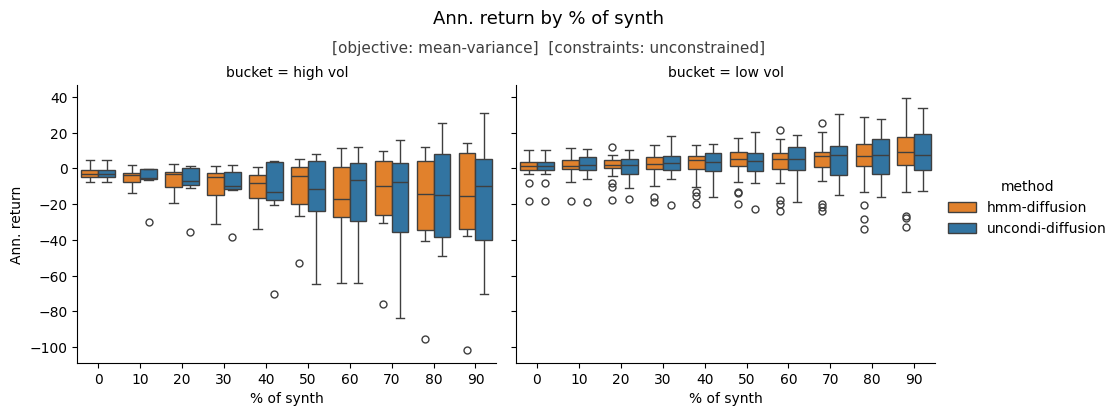

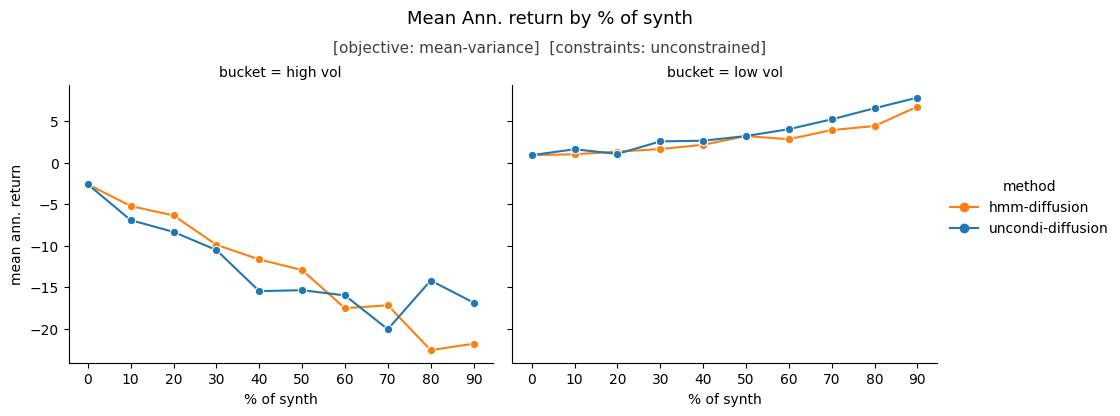

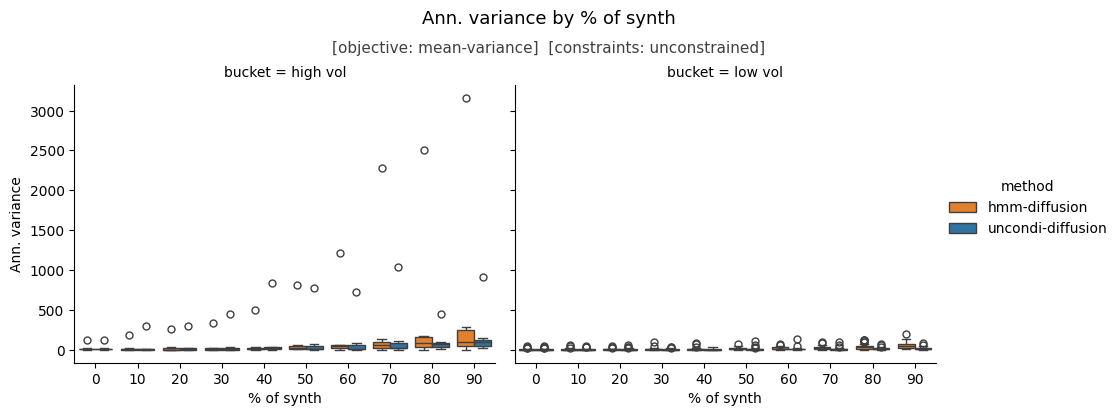

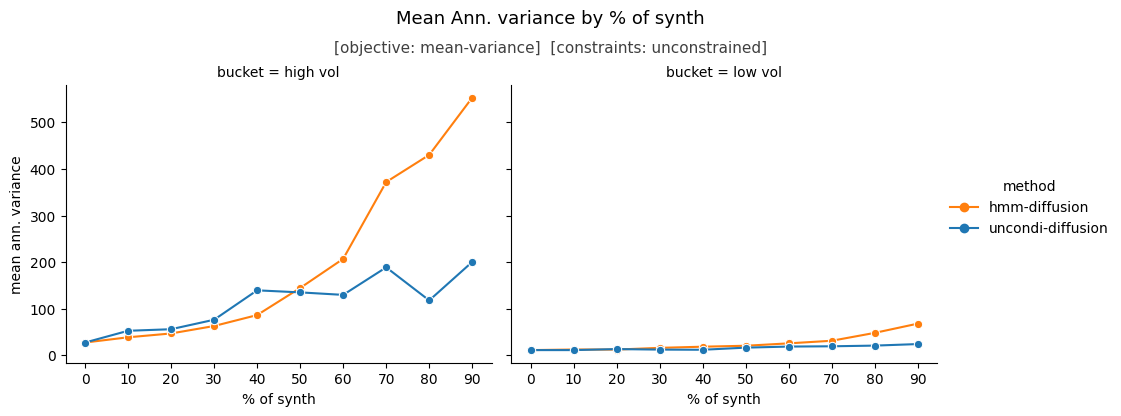

[PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/sharpe/boxes_mean-variance_unconstrained.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/sharpe/means_mean-variance_unconstrained.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/calmar/boxes_mean-variance_unconstrained.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/calmar/means_mean-variance_unconstrained.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/return/boxes_mean-variance_unconstrained.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/return/means_mean-variance_unconstrained.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/variance/boxes_mean-variance_unconstrained.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/variance/means_mean-variance_unconstrained.eps')]

In [9]:
n_assets = len(ASSET_COLS)
synth_rows = [synth_rows_for_share(LOOKBACK, p / 100.0) for p in MIX_GRID]
mix_size = pd.DataFrame(
    {
        "synth_pct": MIX_GRID,
        "real_rows": LOOKBACK,
        "real_cols": n_assets,
        "synth_rows": synth_rows,
        "train_rows": [LOOKBACK + r for r in synth_rows],
        "train_matrix": [f"{LOOKBACK + r} × {n_assets}" for r in synth_rows],
        "synth_row_share": [
            r / (LOOKBACK + r) if r else 0.0 for r in synth_rows
        ],
    }
)
print(
    "Row-append mix: % of synth is synth_rows / (real_rows + synth_rows). "
    "Real lookback stays 252 × 10. 10% adds 28 days; 20% adds 63 days; 90% adds 2268 days."
)
display(mix_size)

display(result.summary.sort_values(["bucket", "n_synth", "method"]))
plots.export_mvo_plots(
    result.windows,
    PLOT_ROOT,
    objective="mean-variance",
    constraint="unconstrained",
)


## Long-only MVO

Same mix, holds, and seeds as the unconstrained sweep. `allow_short=False` clips negative weights on the 10 assets, then renormalizes. This is clip-and-renorm, not a QP with `w ≥ 0`. `n=0` long-only will not match unconstrained `n=0`.


,method,n_synth,synth_pct,bucket,n_windows,sharpe_mean,sharpe_median,calmar_mean,calmar_median,return_mean,return_median,variance_mean,variance_median
0,hmm-diffusion,0,0.0000,high vol,7,-0.5412,-0.1410,0.5122,-0.2394,-0.0961,-0.0125,0.0149,0.0081
20,uncondi-diffusion,0,0.0000,high vol,7,-0.5412,-0.1410,0.5122,-0.2394,-0.0961,-0.0125,0.0149,0.0081
2,hmm-diffusion,10,10.0000,high vol,7,-0.4823,-0.7219,0.5411,-1.1881,-0.1162,-0.0492,0.0178,0.0095
22,uncondi-diffusion,10,10.0000,high vol,7,-0.7634,-1.4923,0.5311,-1.6658,-0.1241,-0.0775,0.0141,0.0074
4,hmm-diffusion,20,20.0000,high vol,7,-0.5273,-0.4492,1.2436,-0.8565,-0.1024,-0.0324,0.0129,0.0062
24,uncondi-diffusion,20,20.0000,high vol,7,-0.2425,-0.3492,2.3288,-0.6488,-0.1035,-0.0214,0.0119,0.0067
6,hmm-diffusion,30,30.0000,high vol,7,-0.6852,-0.8320,1.3215,-1.5900,-0.1192,-0.0428,0.0124,0.0085
26,uncondi-diffusion,30,30.0000,high vol,7,-0.8368,-1.4891,0.8841,-1.5063,-0.1166,-0.0753,0.0099,0.0061
8,hmm-diffusion,40,40.0000,high vol,7,-0.6625,-0.3407,0.9618,-0.6499,-0.0920,-0.0235,0.0107,0.0056
28,uncondi-diffusion,40,40.0000,high vol,7,-0.8487,-1.7413,1.1524,-1.6719,-0.1025,-0.0920,0.0078,0.0034


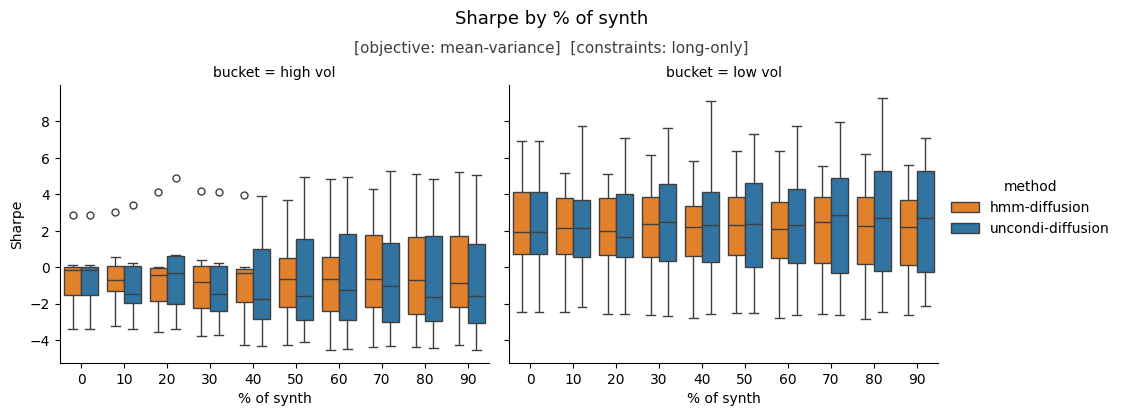

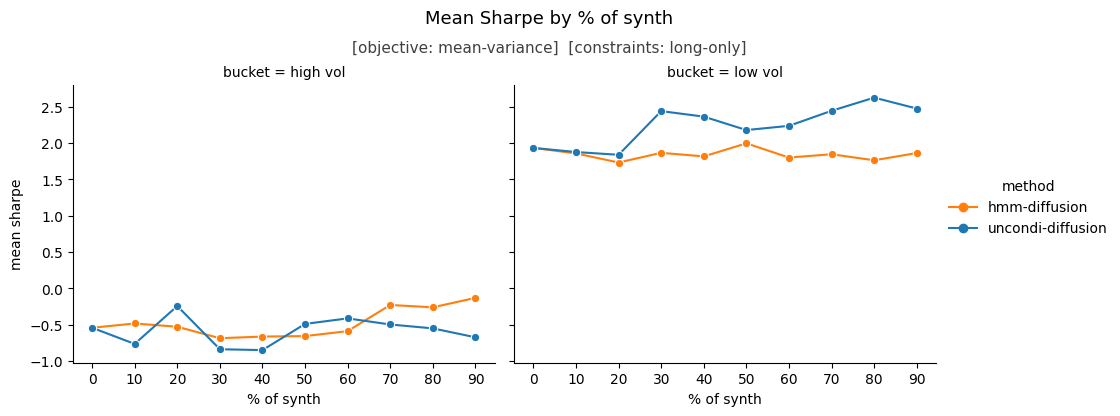

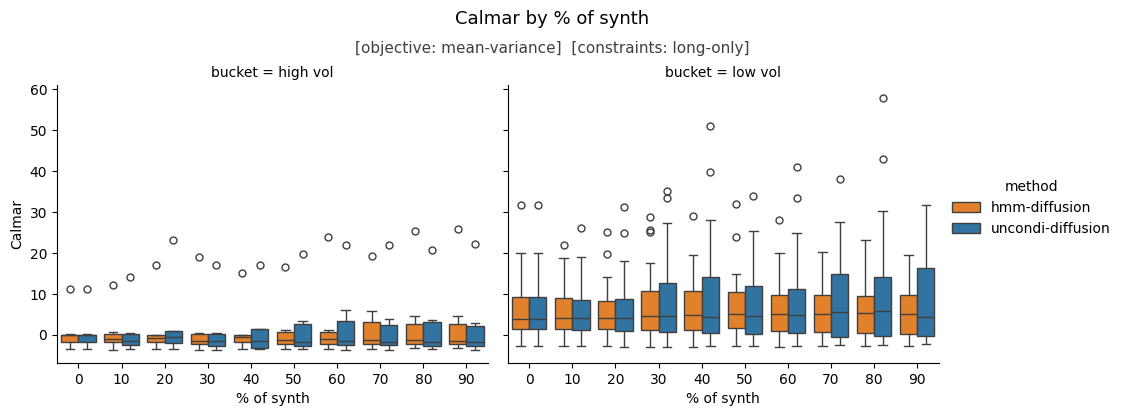

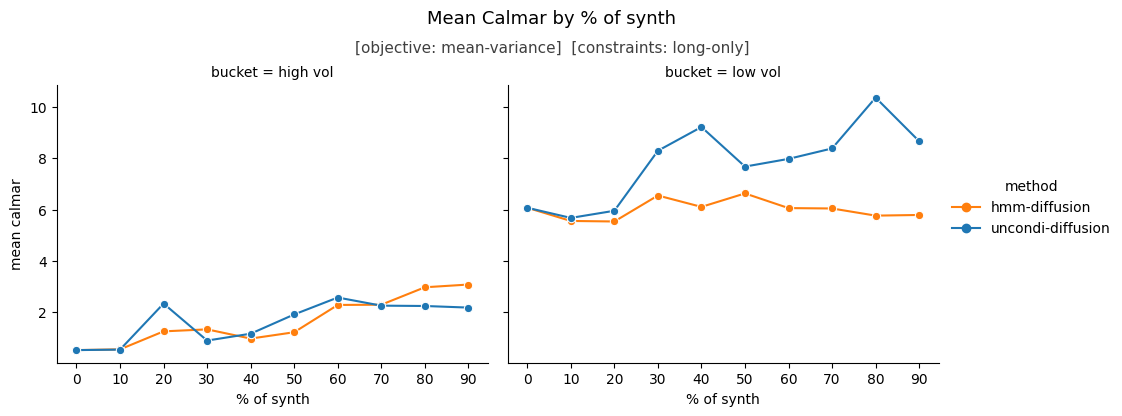

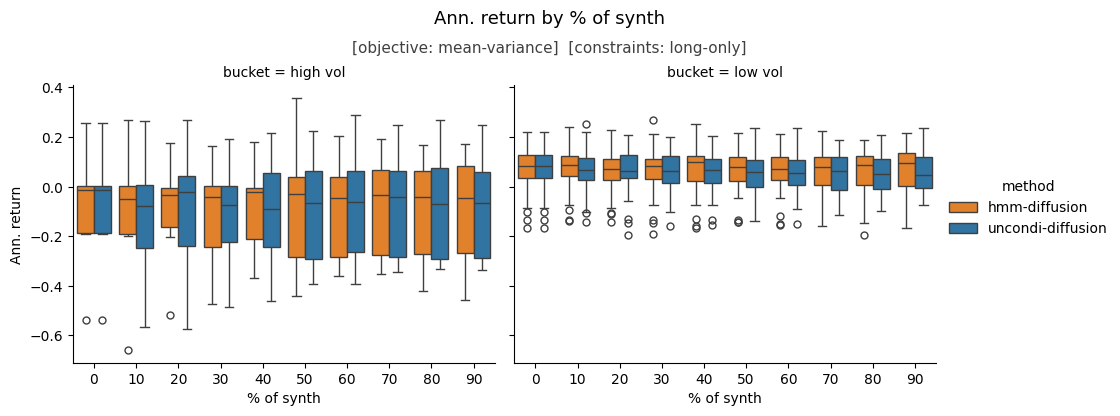

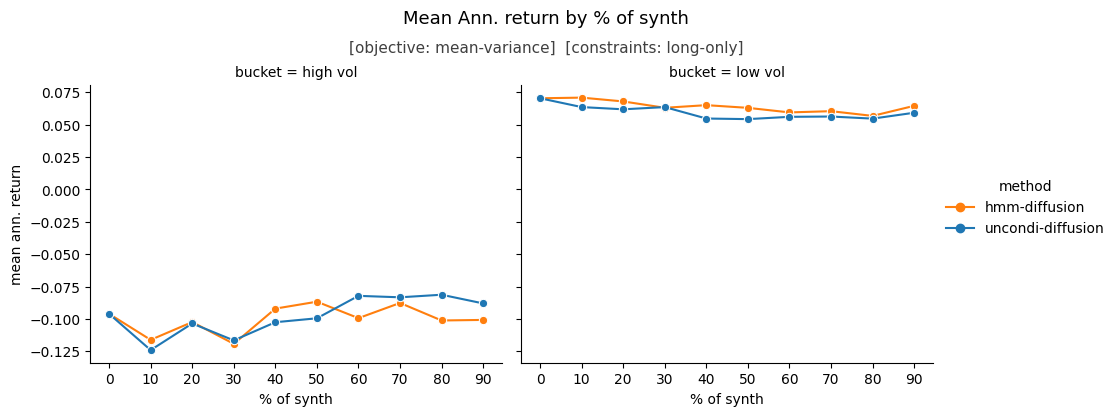

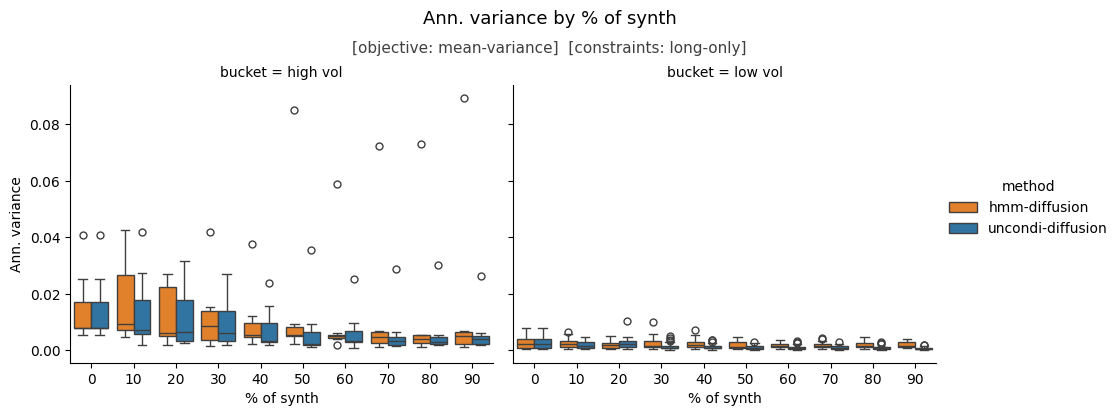

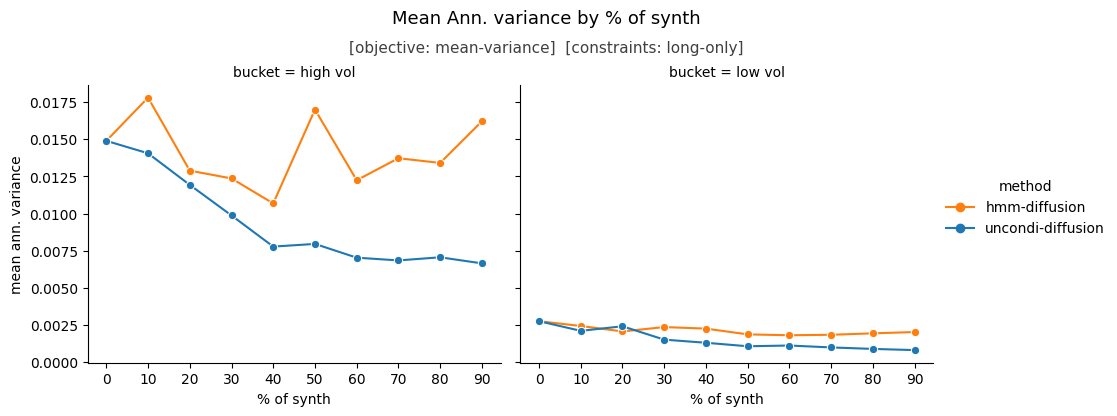

[PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/sharpe/boxes_mean-variance_long-only.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/sharpe/means_mean-variance_long-only.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/calmar/boxes_mean-variance_long-only.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/calmar/means_mean-variance_long-only.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/return/boxes_mean-variance_long-only.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/return/means_mean-variance_long-only.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/variance/boxes_mean-variance_long-only.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/variance/means_mean-variance_long-only.eps')]

In [10]:
result_long_only = run_mvo_backtest(
    simple_panel[ASSET_COLS],
    test_dates.to_numpy(),
    test_regimes,
    walk,
    specialist_pools,
    uncond_windows,
    MIX_GRID,
    lookback=LOOKBACK,
    horizon=HORIZON,
    random_state=RANDOM_STATE,
    allow_short=False,
    mix_mode=MIX_MODE,
)

display(result_long_only.summary.sort_values(["bucket", "n_synth", "method"]))
plots.export_mvo_plots(
    result_long_only.windows,
    PLOT_ROOT,
    objective="mean-variance",
    constraint="long-only",
)


## Long-only 30% cap

Same mix, holds, and seeds. After Markowitz, the 10 traded weights are projected onto `sum w = 1`, `w ≥ 0`, and `w ≤ 0.30`. That is a standard name cap: no asset can be more than 30% of the book.


,method,n_synth,synth_pct,bucket,n_windows,sharpe_mean,sharpe_median,calmar_mean,calmar_median,return_mean,return_median,variance_mean,variance_median
0,hmm-diffusion,0,0.0000,high vol,7,-0.5396,-0.3281,0.2565,-0.4669,-0.0938,-0.0339,0.0212,0.0131
20,uncondi-diffusion,0,0.0000,high vol,7,-0.5396,-0.3281,0.2565,-0.4669,-0.0938,-0.0339,0.0212,0.0131
2,hmm-diffusion,10,10.0000,high vol,7,-0.4609,-0.4789,0.4120,-0.6404,-0.1000,-0.0509,0.0229,0.0142
22,uncondi-diffusion,10,10.0000,high vol,7,-0.6039,-0.4790,0.2984,-0.9139,-0.1103,-0.0444,0.0201,0.0133
4,hmm-diffusion,20,20.0000,high vol,7,-0.6571,-0.2540,0.2606,-0.3683,-0.1065,-0.0225,0.0213,0.0172
24,uncondi-diffusion,20,20.0000,high vol,7,-0.3962,-0.3213,0.9042,-0.5971,-0.0958,-0.0204,0.0149,0.0112
6,hmm-diffusion,30,30.0000,high vol,7,-0.6891,-0.2786,0.1875,-0.5629,-0.1143,-0.0311,0.0195,0.0124
26,uncondi-diffusion,30,30.0000,high vol,7,-0.6700,-0.4737,0.2396,-0.8825,-0.1001,-0.0411,0.0166,0.0141
8,hmm-diffusion,40,40.0000,high vol,7,-0.7109,-0.2778,0.2029,-0.5344,-0.0980,-0.0198,0.0169,0.0112
28,uncondi-diffusion,40,40.0000,high vol,7,-0.5790,-0.4766,0.5278,-0.8799,-0.0783,-0.0275,0.0117,0.0070


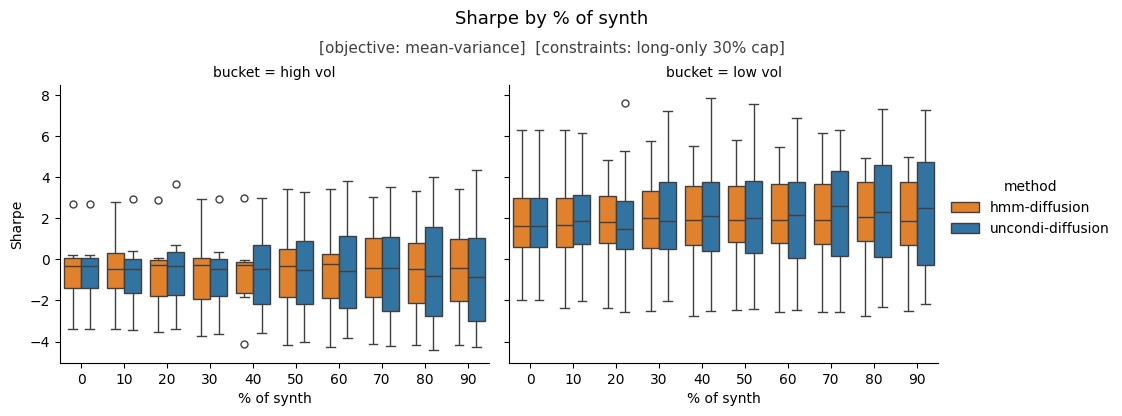

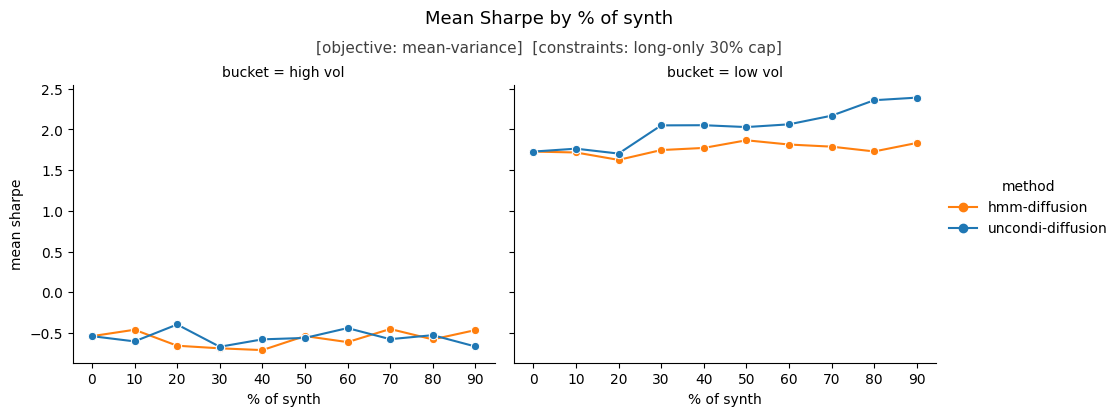

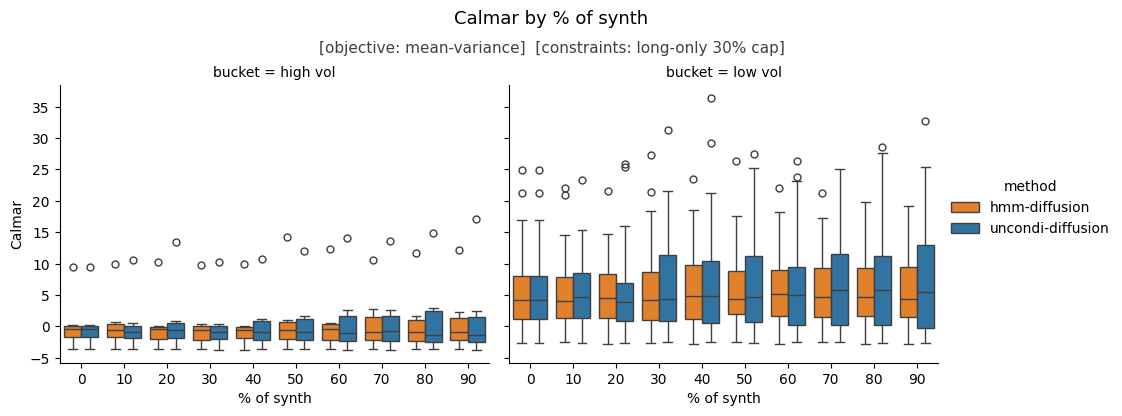

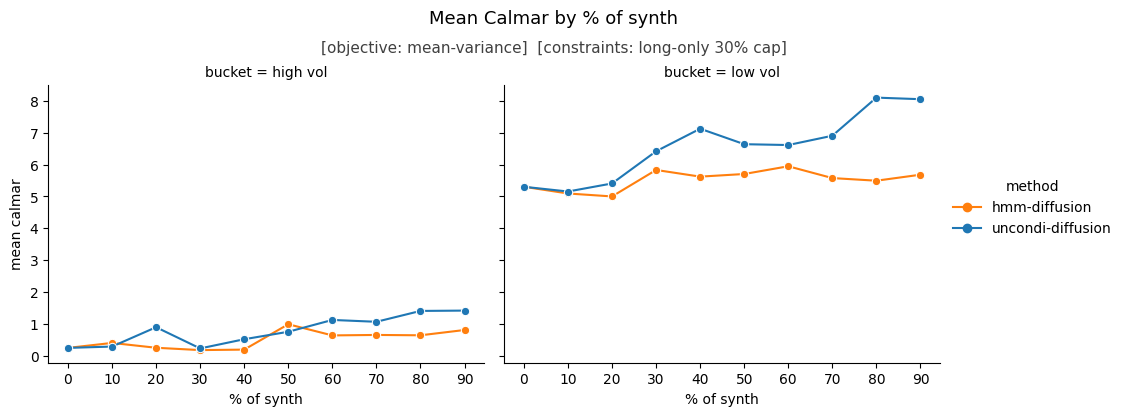

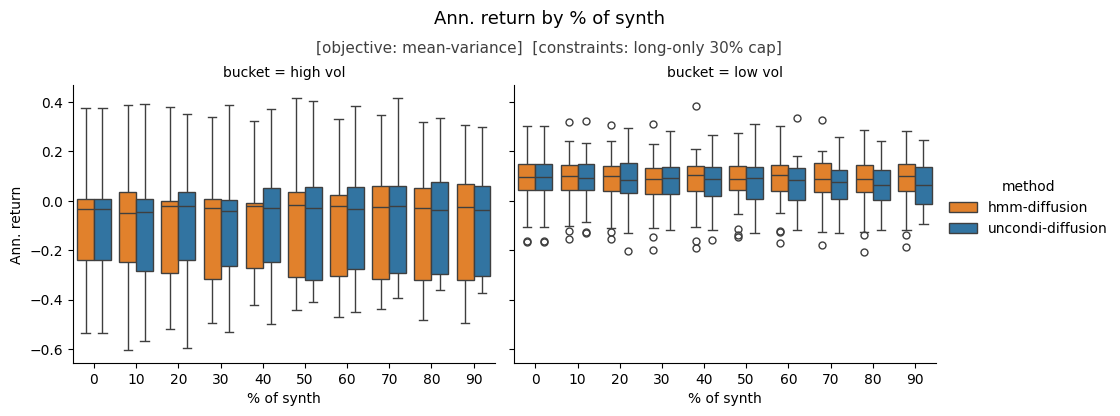

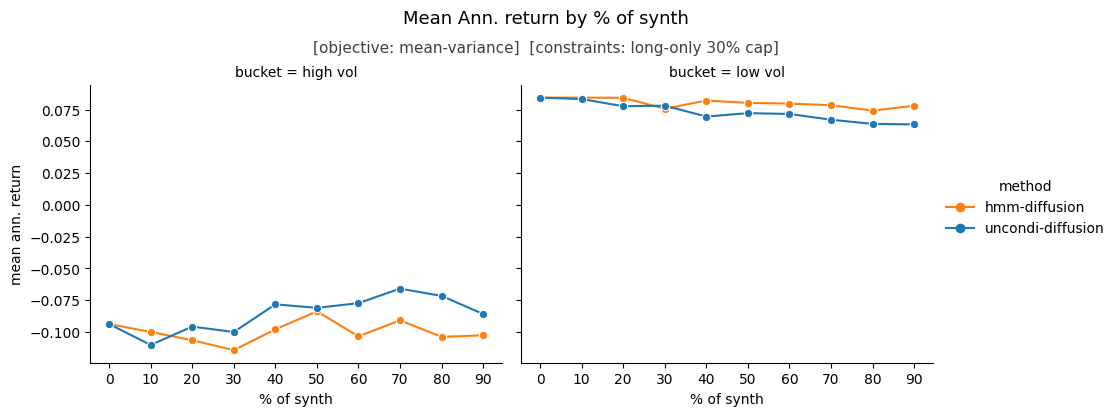

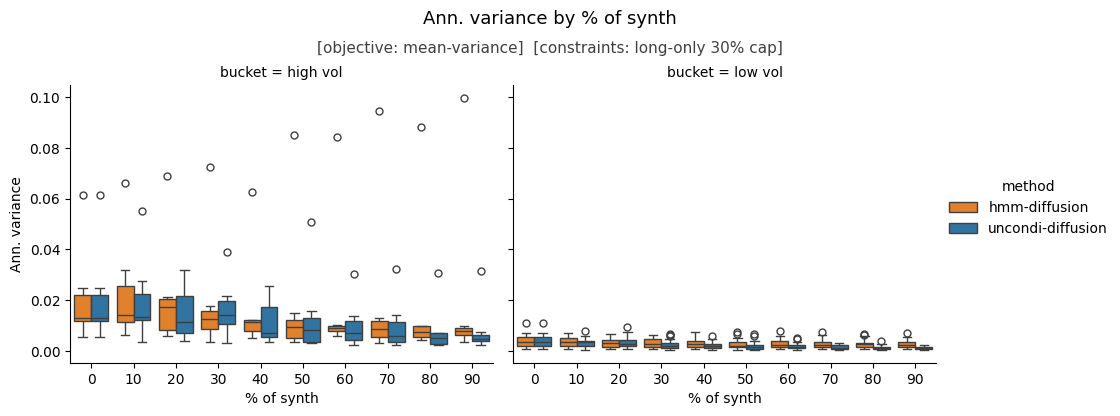

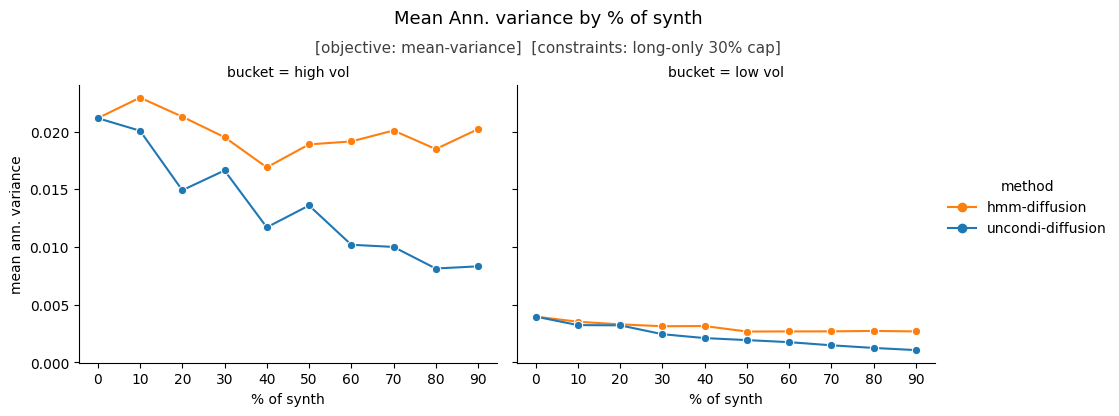

[PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/sharpe/boxes_mean-variance_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/sharpe/means_mean-variance_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/calmar/boxes_mean-variance_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/calmar/means_mean-variance_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/return/boxes_mean-variance_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/return/means_mean-variance_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/variance/boxes_mean-variance_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/variance/means_mean-variance_long-only-30pct-cap.eps')]

In [11]:
MAX_WEIGHT = 0.30
result_capped = run_mvo_backtest(
    simple_panel[ASSET_COLS],
    test_dates.to_numpy(),
    test_regimes,
    walk,
    specialist_pools,
    uncond_windows,
    MIX_GRID,
    lookback=LOOKBACK,
    horizon=HORIZON,
    random_state=RANDOM_STATE,
    allow_short=False,
    max_weight=MAX_WEIGHT,
    mix_mode=MIX_MODE,
)

display(result_capped.summary.sort_values(["bucket", "n_synth", "method"]))
plots.export_mvo_plots(
    result_capped.windows,
    PLOT_ROOT,
    objective="mean-variance",
    constraint="long-only 30% cap",
)


## Long-only 30% cap, max Sharpe

Same mix, holds, seeds, long-only, and 30% name cap as the previous cell. Weights maximize Sharpe (`w ∝ Σ^{-1} μ`, rf = 0) on the row-appended 10-asset matrix, then project onto `w ≥ 0`, `w ≤ 0.30`, `sum w = 1`.


,method,n_synth,synth_pct,bucket,n_windows,sharpe_mean,sharpe_median,calmar_mean,calmar_median,return_mean,return_median,variance_mean,variance_median
0,hmm-diffusion,0,0.0000,high vol,7,-0.5495,-0.6569,0.4033,-1.1546,-0.1164,-0.0317,0.0138,0.0076
20,uncondi-diffusion,0,0.0000,high vol,7,-0.5495,-0.6569,0.4033,-1.1546,-0.1164,-0.0317,0.0138,0.0076
2,hmm-diffusion,10,10.0000,high vol,7,-0.4469,-0.4764,0.5678,-0.9485,-0.1004,-0.0238,0.0119,0.0069
22,uncondi-diffusion,10,10.0000,high vol,7,-0.6005,-1.0724,0.4493,-1.5385,-0.1109,-0.0402,0.0114,0.0057
4,hmm-diffusion,20,20.0000,high vol,7,-0.4800,-0.4621,0.6492,-0.8752,-0.0900,-0.0256,0.0092,0.0058
24,uncondi-diffusion,20,20.0000,high vol,7,-0.5006,-0.9612,0.5087,-1.4552,-0.0983,-0.0389,0.0104,0.0076
6,hmm-diffusion,30,30.0000,high vol,7,-0.6311,-0.8775,0.3996,-1.4575,-0.0946,-0.0340,0.0082,0.0049
26,uncondi-diffusion,30,30.0000,high vol,7,-0.6517,-1.2472,0.4326,-1.5480,-0.0977,-0.0409,0.0090,0.0053
8,hmm-diffusion,40,40.0000,high vol,7,-0.6352,-0.7198,0.5444,-1.3121,-0.0803,-0.0332,0.0067,0.0040
28,uncondi-diffusion,40,40.0000,high vol,7,-0.4869,-0.8377,0.8391,-1.4956,-0.0846,-0.0351,0.0074,0.0042


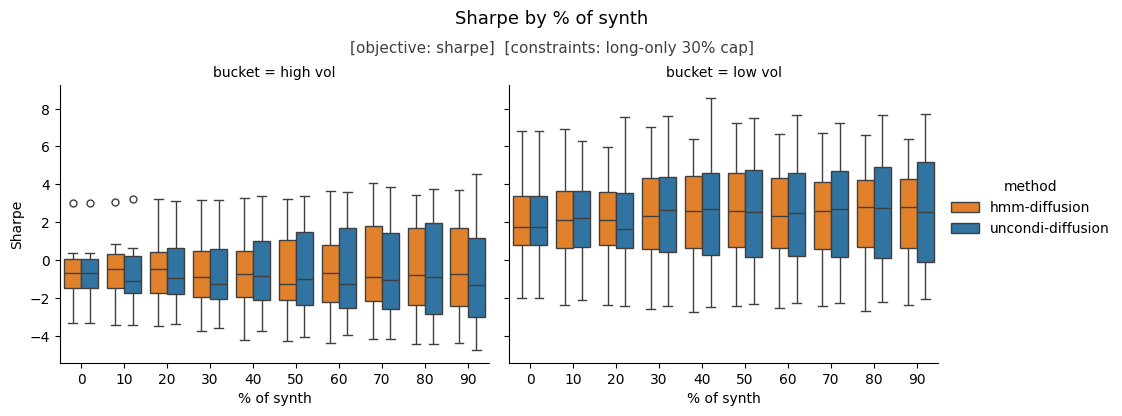

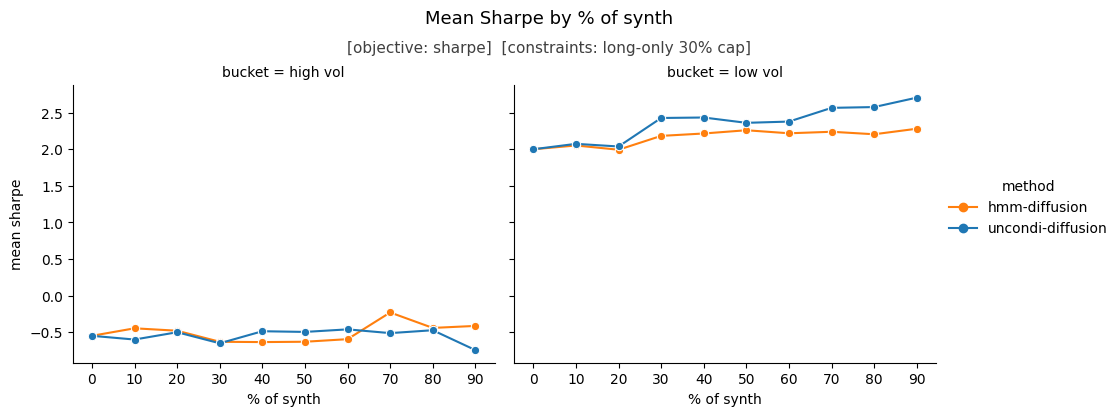

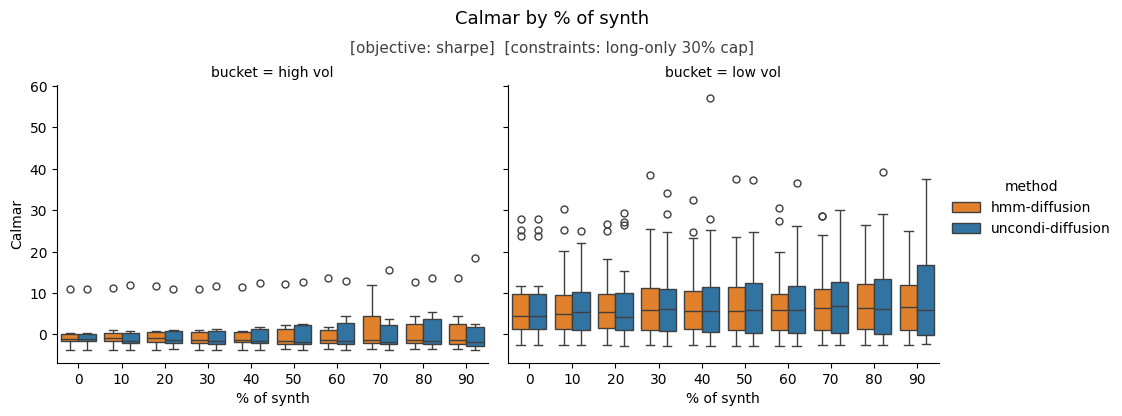

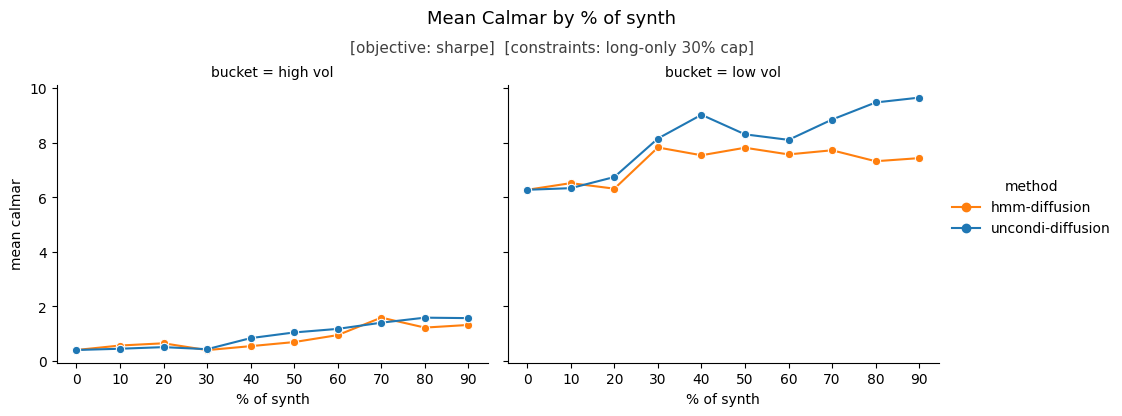

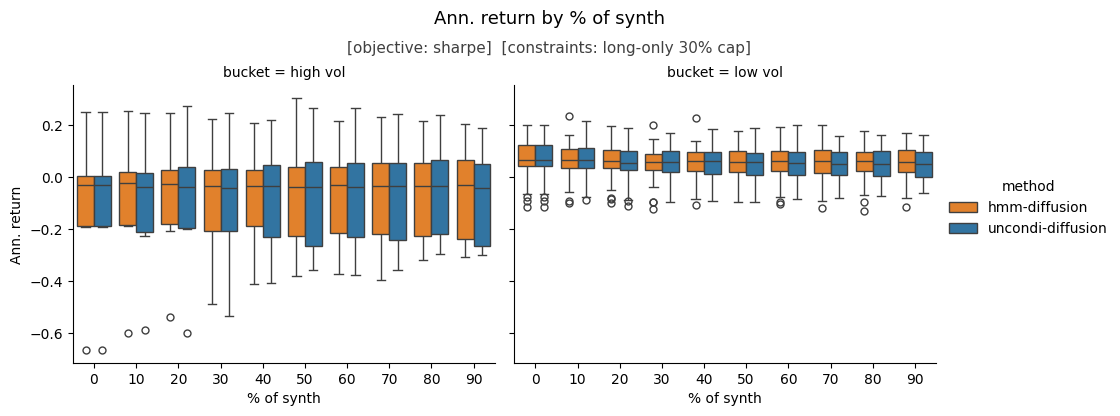

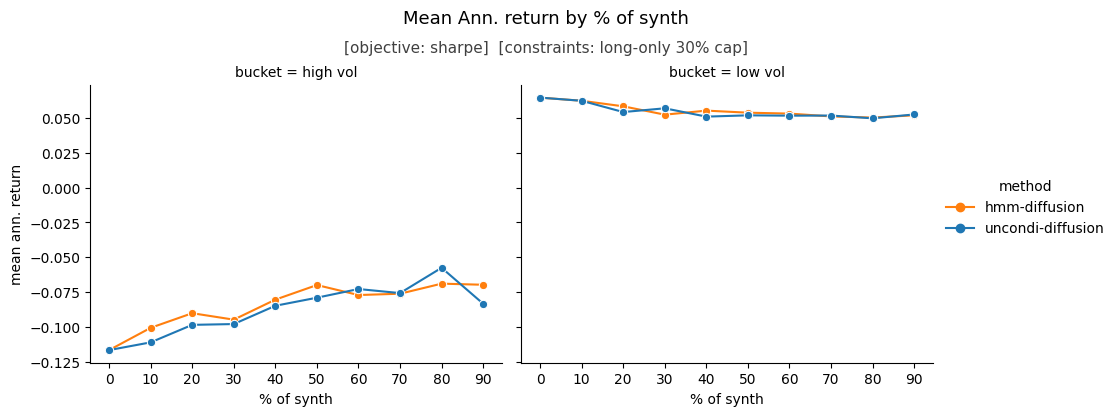

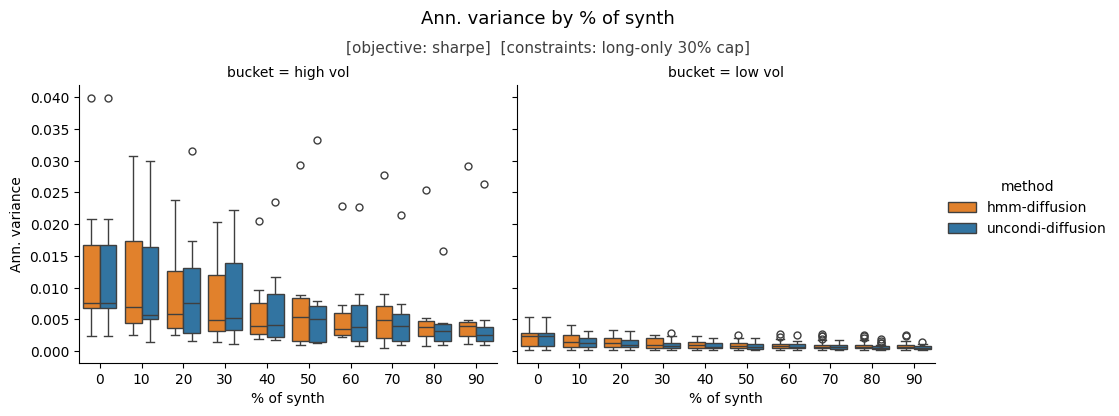

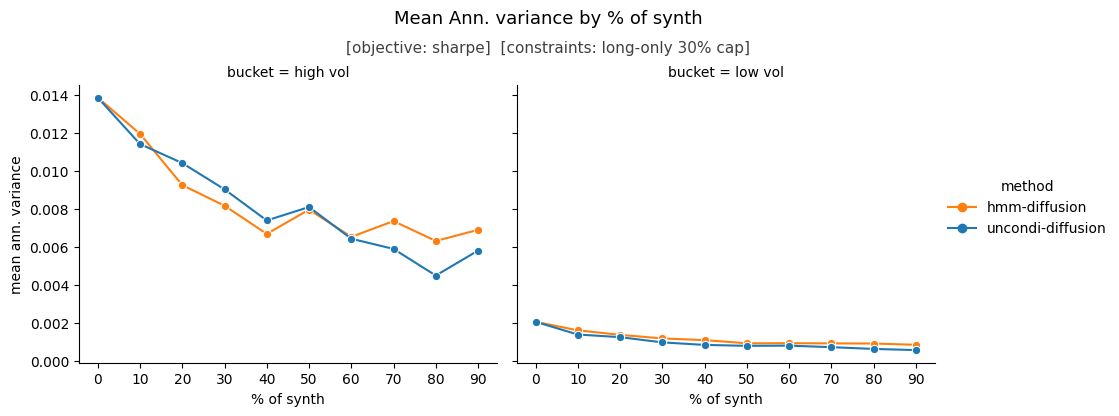

[PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/sharpe/boxes_sharpe_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/sharpe/means_sharpe_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/calmar/boxes_sharpe_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/calmar/means_sharpe_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/return/boxes_sharpe_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/return/means_sharpe_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/variance/boxes_sharpe_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/variance/means_sharpe_long-only-30pct-cap.eps')]

In [12]:
MAX_WEIGHT = 0.30
result_max_sharpe = run_mvo_backtest(
    simple_panel[ASSET_COLS],
    test_dates.to_numpy(),
    test_regimes,
    walk,
    specialist_pools,
    uncond_windows,
    MIX_GRID,
    lookback=LOOKBACK,
    horizon=HORIZON,
    random_state=RANDOM_STATE,
    allow_short=False,
    max_weight=MAX_WEIGHT,
    objective="max_sharpe",
    mix_mode=MIX_MODE,
)

display(result_max_sharpe.summary.sort_values(["bucket", "n_synth", "method"]))
plots.export_mvo_plots(
    result_max_sharpe.windows,
    PLOT_ROOT,
    objective="sharpe",
    constraint="long-only 30% cap",
)


## Long-only 30% cap, min variance

Same mix, holds, seeds, long-only, and 30% name cap. Weights are global minimum variance (`w ∝ Σ^{-1} 1`) on the row-appended 10-asset matrix, then project onto the 30% cap.


,method,n_synth,synth_pct,bucket,n_windows,sharpe_mean,sharpe_median,calmar_mean,calmar_median,return_mean,return_median,variance_mean,variance_median
0,hmm-diffusion,0,0.0000,high vol,7,-0.6713,-0.2400,0.3751,-0.4641,-0.0625,-0.0112,0.0094,0.0044
20,uncondi-diffusion,0,0.0000,high vol,7,-0.6713,-0.2400,0.3751,-0.4641,-0.0625,-0.0112,0.0094,0.0044
2,hmm-diffusion,10,10.0000,high vol,7,-0.6222,-0.1548,0.4050,-0.3031,-0.0635,-0.0073,0.0098,0.0044
22,uncondi-diffusion,10,10.0000,high vol,7,-0.6321,0.0539,0.4371,0.1080,-0.0640,0.0028,0.0103,0.0045
4,hmm-diffusion,20,20.0000,high vol,7,-0.6868,-0.2814,0.3456,-0.5378,-0.0633,-0.0135,0.0095,0.0042
24,uncondi-diffusion,20,20.0000,high vol,7,-0.6949,-0.2659,0.3388,-0.5138,-0.0750,-0.0124,0.0110,0.0041
6,hmm-diffusion,30,30.0000,high vol,7,-0.6817,-0.2476,0.3483,-0.4776,-0.0609,-0.0116,0.0091,0.0048
26,uncondi-diffusion,30,30.0000,high vol,7,-0.5997,-0.0314,0.4800,-0.0439,-0.0644,-0.0024,0.0101,0.0056
8,hmm-diffusion,40,40.0000,high vol,7,-0.7187,-0.5300,0.2936,-0.9872,-0.0614,-0.0244,0.0089,0.0036
28,uncondi-diffusion,40,40.0000,high vol,7,-0.6565,-0.1857,0.3840,-0.3536,-0.0729,-0.0096,0.0102,0.0052


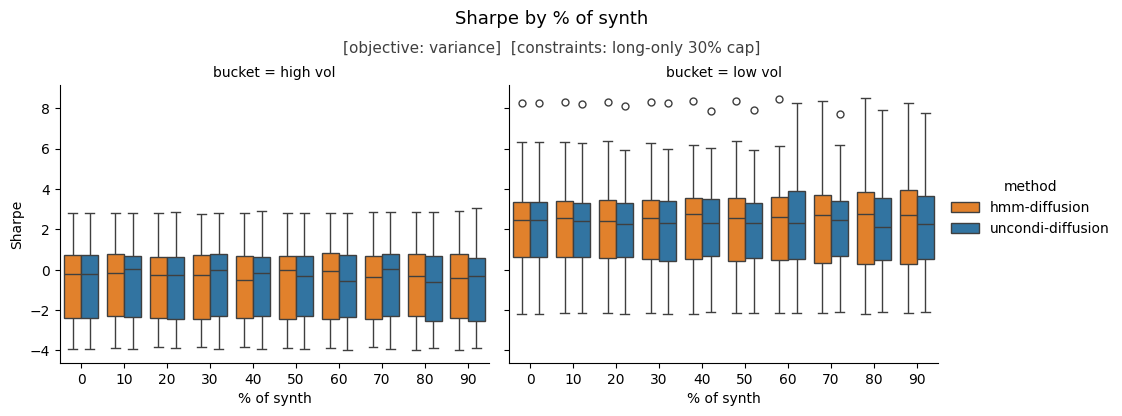

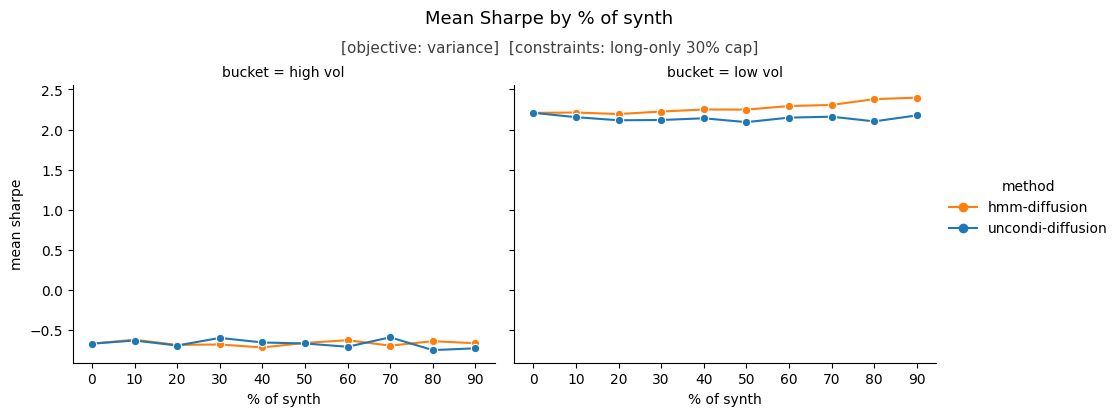

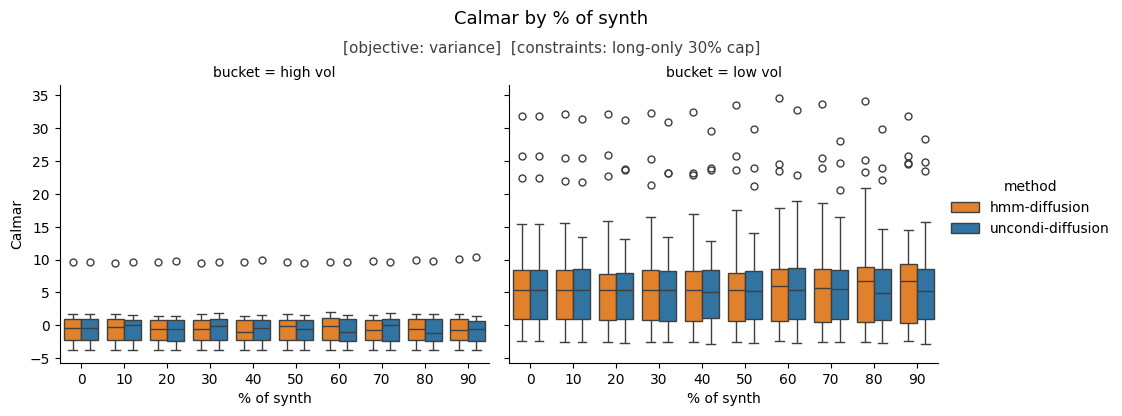

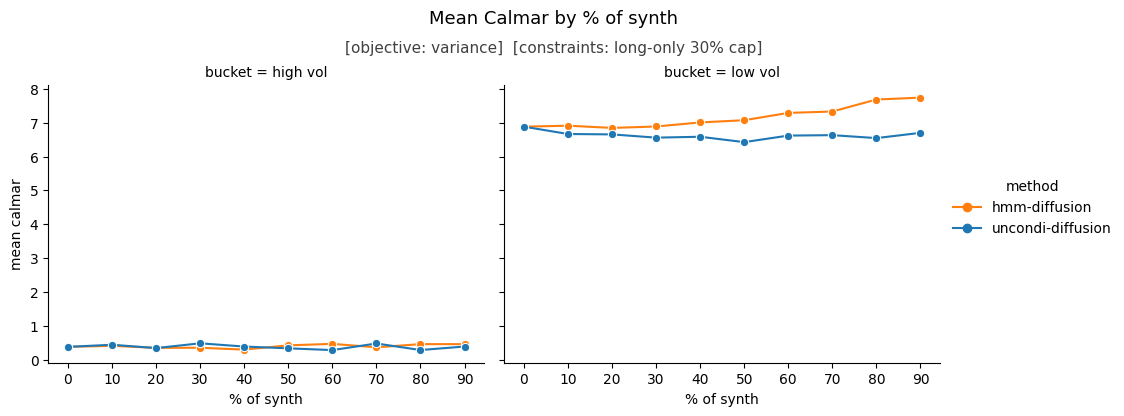

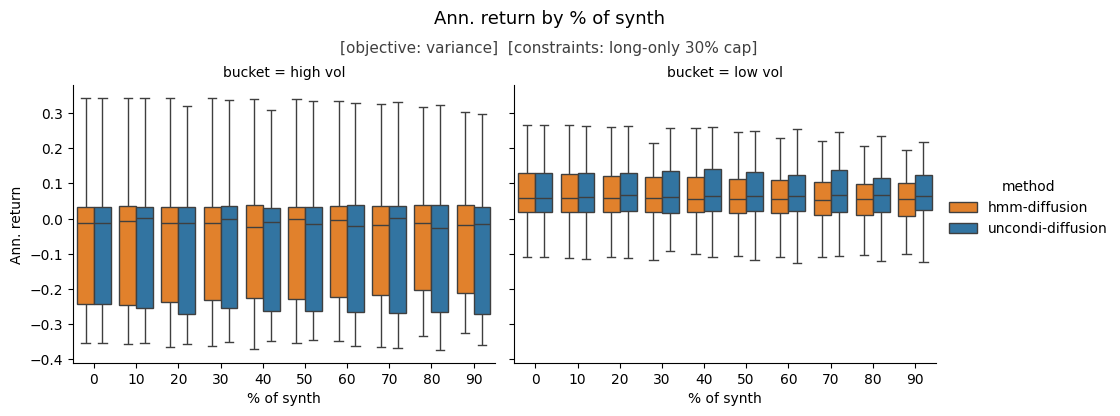

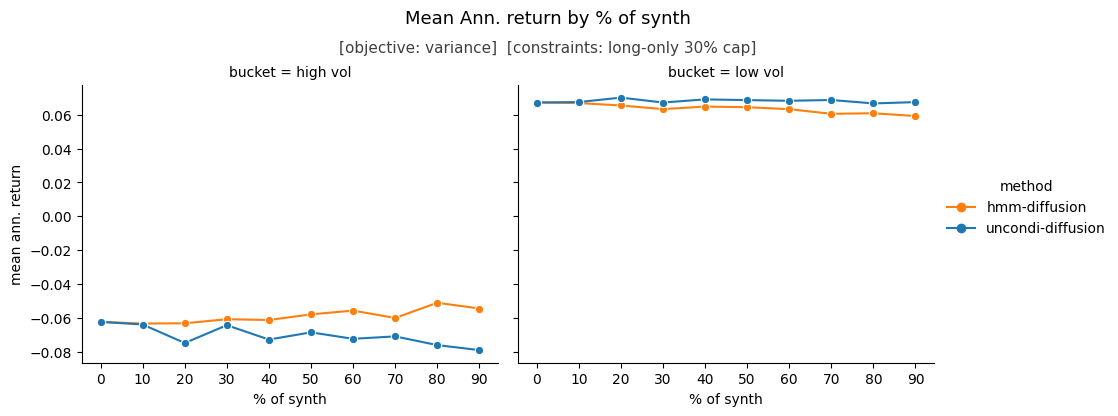

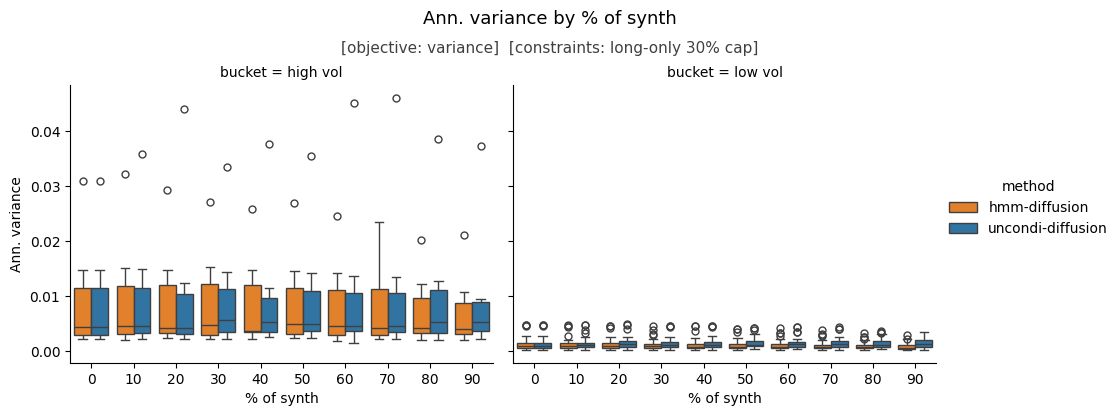

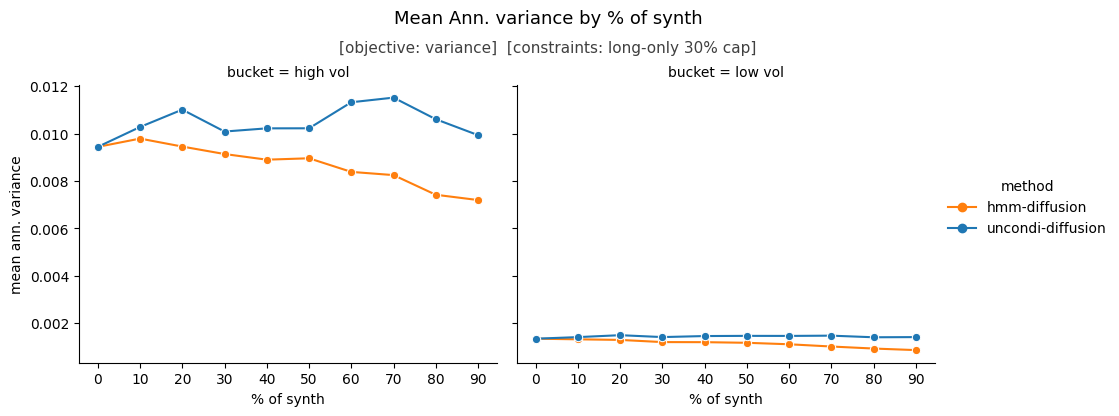

[PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/sharpe/boxes_variance_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/sharpe/means_variance_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/calmar/boxes_variance_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/calmar/means_variance_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/return/boxes_variance_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/return/means_variance_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/variance/boxes_variance_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/variance/means_variance_long-only-30pct-cap.eps')]

In [13]:
result_min_var = run_mvo_backtest(
    simple_panel[ASSET_COLS],
    test_dates.to_numpy(),
    test_regimes,
    walk,
    specialist_pools,
    uncond_windows,
    MIX_GRID,
    lookback=LOOKBACK,
    horizon=HORIZON,
    random_state=RANDOM_STATE,
    allow_short=False,
    max_weight=MAX_WEIGHT,
    objective="min_variance",
    mix_mode=MIX_MODE,
)

display(result_min_var.summary.sort_values(["bucket", "n_synth", "method"]))
plots.export_mvo_plots(
    result_min_var.windows,
    PLOT_ROOT,
    objective="variance",
    constraint="long-only 30% cap",
)


## Long-only 30% cap, max return

Same mix, holds, seeds, long-only, and 30% name cap. Fill the highest-mean names first: 30% in the best, 30% in the next, and so on, until the weights sum to 1. Means come from the row-appended 10-asset matrix. Covariance is not used.


,method,n_synth,synth_pct,bucket,n_windows,sharpe_mean,sharpe_median,calmar_mean,calmar_median,return_mean,return_median,variance_mean,variance_median
0,hmm-diffusion,0,0.0000,high vol,7,-0.2172,-0.1379,0.7949,-0.1725,-0.2081,-0.0279,0.0755,0.0384
20,uncondi-diffusion,0,0.0000,high vol,7,-0.2172,-0.1379,0.7949,-0.1725,-0.2081,-0.0279,0.0755,0.0384
2,hmm-diffusion,10,10.0000,high vol,7,-0.3518,-0.7858,0.5920,-1.0674,-0.2286,-0.1533,0.0810,0.0384
22,uncondi-diffusion,10,10.0000,high vol,7,-0.2622,-0.3418,0.6526,-0.4674,-0.2097,-0.0426,0.0872,0.0384
4,hmm-diffusion,20,20.0000,high vol,7,-0.3123,-0.5937,0.6176,-0.8444,-0.2304,-0.1195,0.0833,0.0405
24,uncondi-diffusion,20,20.0000,high vol,7,-0.4284,-0.8052,0.0037,-1.1894,-0.1714,-0.1579,0.0818,0.0384
6,hmm-diffusion,30,30.0000,high vol,7,-0.4697,-0.3935,-0.0695,-0.5237,-0.1812,-0.0745,0.0940,0.0452
26,uncondi-diffusion,30,30.0000,high vol,7,-0.5875,-0.8052,-0.2404,-1.1460,-0.2031,-0.1579,0.0779,0.0430
8,hmm-diffusion,40,40.0000,high vol,7,-0.5929,-0.8575,-0.2171,-1.1894,-0.1947,-0.1696,0.0970,0.0430
28,uncondi-diffusion,40,40.0000,high vol,7,-0.4421,-0.6687,-0.0460,-0.9367,-0.1852,-0.1319,0.0886,0.0419


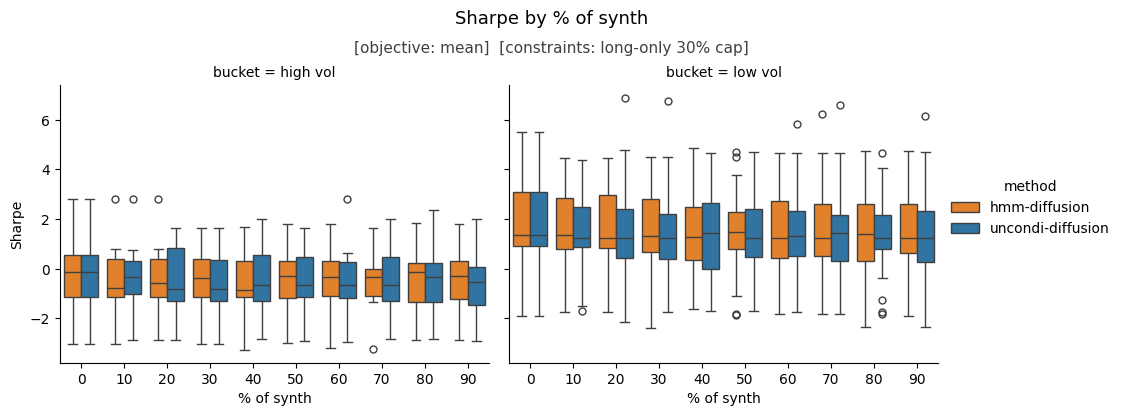

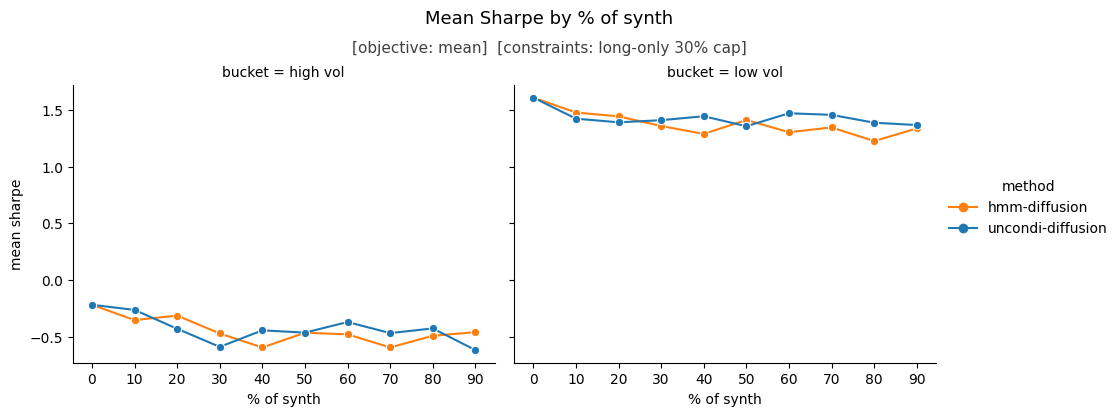

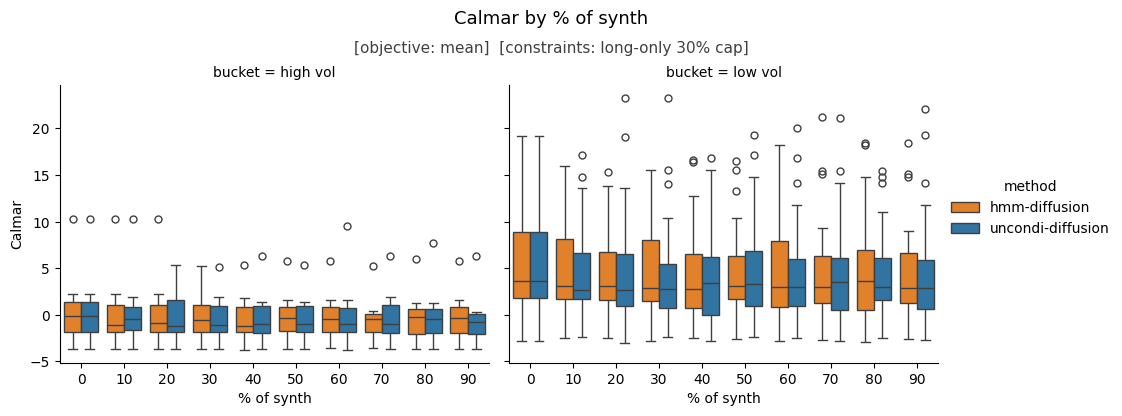

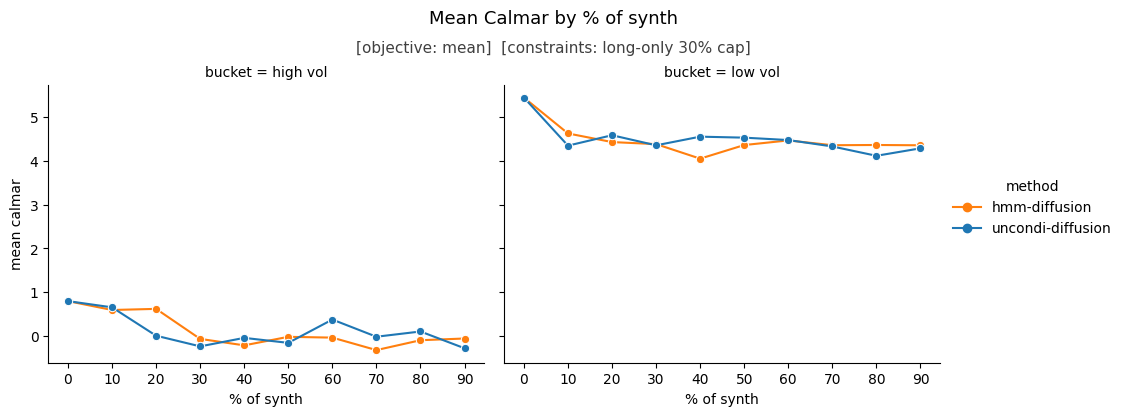

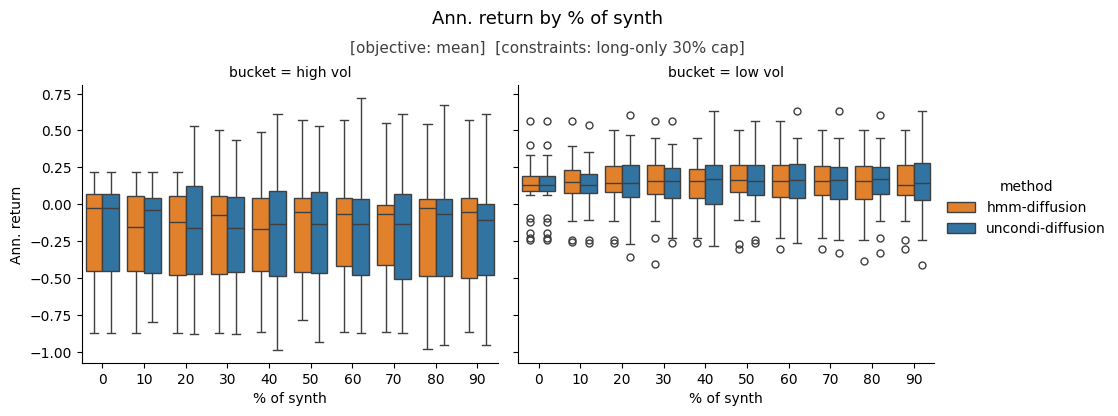

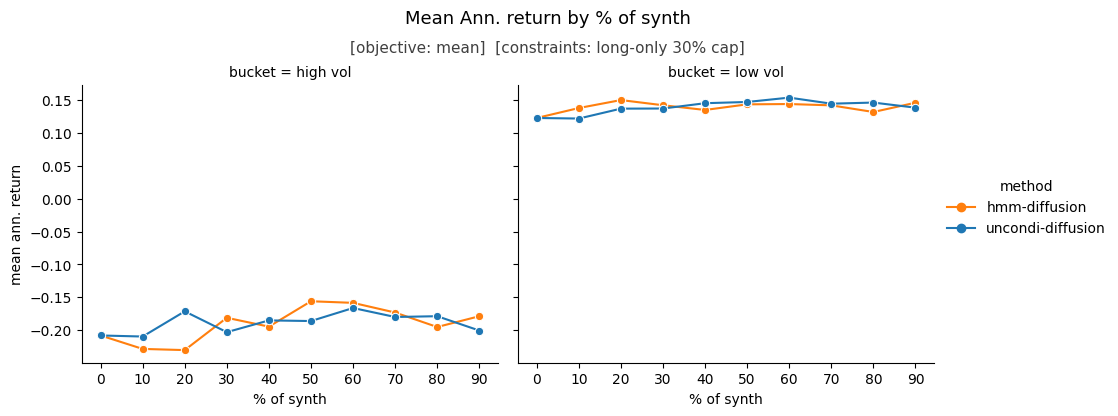

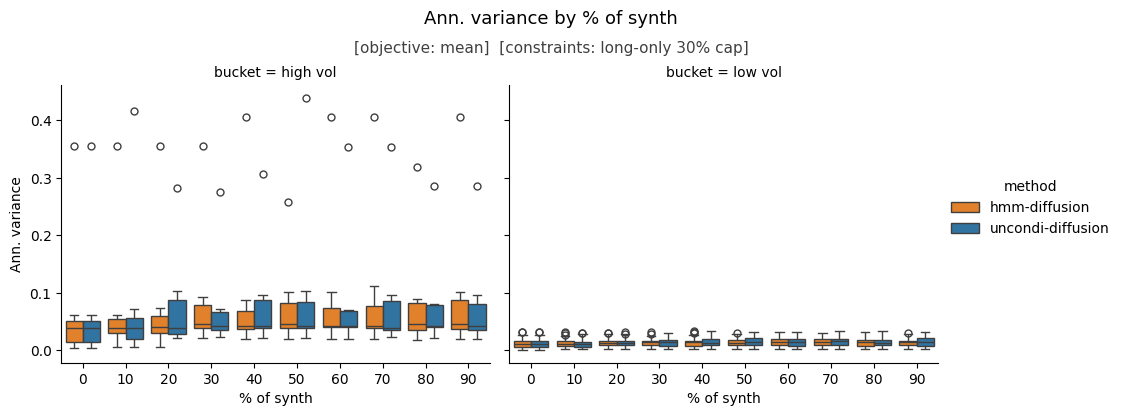

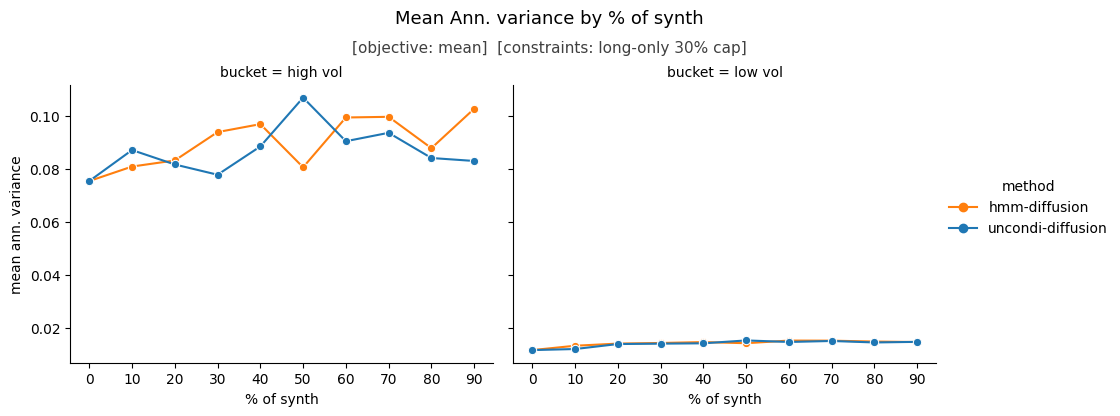

[PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/sharpe/boxes_mean_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/sharpe/means_mean_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/calmar/boxes_mean_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/calmar/means_mean_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/return/boxes_mean_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/return/means_mean_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/variance/boxes_mean_long-only-30pct-cap.eps'),
 PosixPath('/Users/mohanyang/Documents/GitHub/HMM-Diffusion/plots/ew/variance/means_mean_long-only-30pct-cap.eps')]

In [14]:
result_max_return = run_mvo_backtest(
    simple_panel[ASSET_COLS],
    test_dates.to_numpy(),
    test_regimes,
    walk,
    specialist_pools,
    uncond_windows,
    MIX_GRID,
    lookback=LOOKBACK,
    horizon=HORIZON,
    random_state=RANDOM_STATE,
    allow_short=False,
    max_weight=MAX_WEIGHT,
    objective="max_return",
    mix_mode=MIX_MODE,
)

display(result_max_return.summary.sort_values(["bucket", "n_synth", "method"]))
plots.export_mvo_plots(
    result_max_return.windows,
    PLOT_ROOT,
    objective="mean",
    constraint="long-only 30% cap",
)
